# Bank Customer Churn Prediction

This notebook performs:
1. **EDA** – Exploratory Data Analysis on `Bank Customer Churn Prediction.csv`
2. **Feature Engineering** – New features from existing columns
3. **Preprocessing** – Encoding, scaling, train/test split
4. **Modeling** – Six classifiers with evaluation

In [1]:
#libraries we need for this project
import pandas as pd        
import numpy as np         
import matplotlib.pyplot as plt  
import seaborn as sns      


from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from imblearn.over_sampling import SMOTE  # we use this to handle the class imbalance
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, silhouette_score
)

# to keep the output clean
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

In [2]:
# loaded the dataset from the CSV file into a dataframe
df = pd.read_csv(r"C:\Users\Asus\Downloads\Bank Customer Churn Prediction.csv")
# printed the shape to see how many rows and columns we have
print("Shape:", df.shape)
# and displayed the first 5 rows to get an initial look at the data
df.head()

Shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


---
## 1. Exploratory Data Analysis (EDA)

In [3]:
# to check the data types of each column and see if there are any null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [4]:
# to check if there are any missing values in each column
print("Missing values per column:")
print(df.isnull().sum())
# We also checked for duplicate rows in the dataset
print("\nDuplicates:", df.duplicated().sum())

Missing values per column:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Duplicates: 0


- The dataset has no null or missing values 

In [5]:
# describe() to get the statistical summary of all columns
# This shows us the count, mean, std, min, max, and quartiles for numeric features
# and count, unique, top, freq for categorical features
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
credit_score,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
country,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
products_number,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
credit_card,10000.0,NaN,NaN,NaN,0.7055,0.45584,0.0,0.0,1.0,1.0,1.0
active_member,10000.0,NaN,NaN,NaN,0.5151,0.499797,0.0,0.0,1.0,1.0,1.0


**Summary Statistics:**
- **credit_score** ranges from 350 to 850 (mean ≈ 651), approximately normally distributed.
- **age** ranges from 18 to 92 (mean ≈ 39), slightly right-skewed with most customers between 30–45.
- **tenure** ranges from 0 to 10 years (mean ≈ 5), roughly uniformly distributed.
- **balance** ranges from 0 to ~250,898 (mean ≈ 76,486). The large standard deviation (62,397) and 25th percentile of 0 indicate many customers hold zero balance.
- **products_number** is mostly 1 or 2 (mean ≈ 1.53), very few customers have 3 or 4 products.
- **credit_card** and **active_member** are binary features 70.6% of customers have a credit card, 51.5% are active members.
- **estimated_salary** ranges from ~12 to ~200,000 (mean ≈ 100,090), approximately uniformly distributed.
- **churn** (target): mean = 0.204, confirming the 20.4% churn rate.
- **country** has 3 unique values (top: France, 5,014 customers). **gender** has 2 unique values (top: Male, 5,457 customers).
 - NaN values in the table are not missing data they indicate that a statistic does not apply to that column type (e.g., `mean` is not applicable to categorical columns).

**How balanced is the target variable in this dataset?**

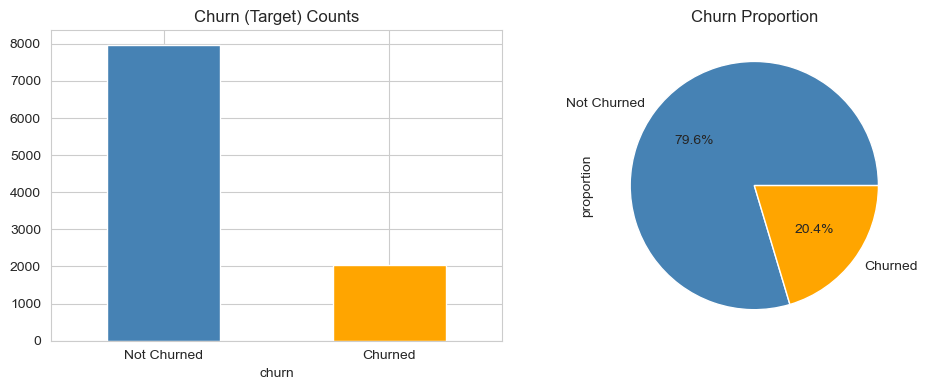

Churn rate: 0.204
Not churned rate: 0.796


In [6]:
# Here we visualized the target variable (churn) to see the class distribution
# a bar chart and a pie chart side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart showing the count of churned vs not churned
df["churn"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["steelblue", "orange"])
axes[0].set_title("Churn (Target) Counts")
axes[0].set_xticklabels(["Not Churned", "Churned"], rotation=0)

# Pie chart showing the proportion of each class
df["churn"].value_counts(normalize=True).sort_index().plot(kind="pie", ax=axes[1], autopct="%1.1f%%", labels=["Not Churned", "Churned"], colors=["steelblue", "orange"])
axes[1].set_title("Churn Proportion")
plt.tight_layout()
plt.show()

# printed the exact churn rate to confirm the imbalance
print("Churn rate:", df["churn"].mean().round(3))
print("Not churned rate:", (1 - df["churn"].mean()).round(3))

- The dataset is imbalanced: ~79.6% not churned vs ~20.4% churned. 


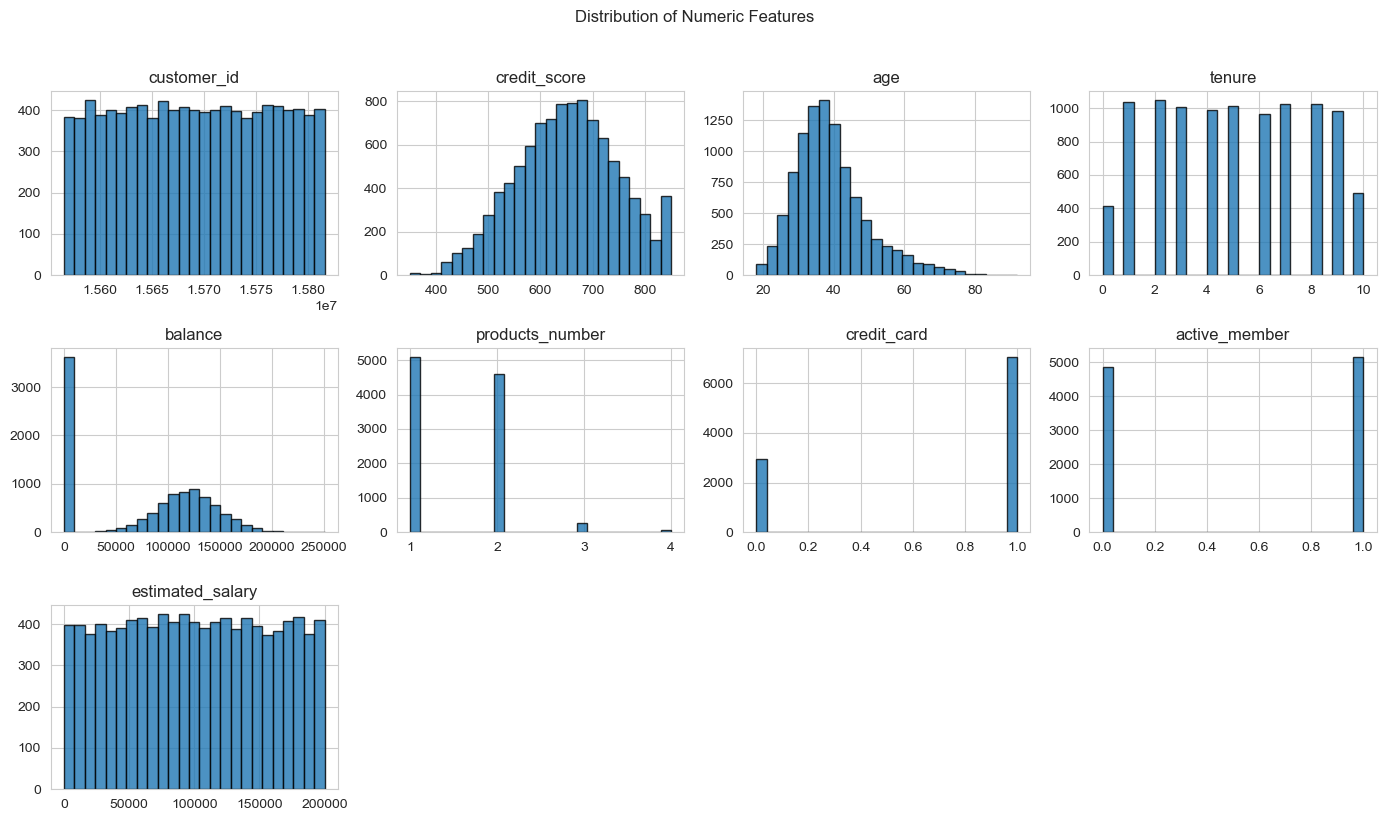

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop("churn", errors="ignore")
df[numeric_cols].hist(bins=25, figsize=(14, 8), layout=(3, 4), edgecolor="black", alpha=0.8)
plt.suptitle("Distribution of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

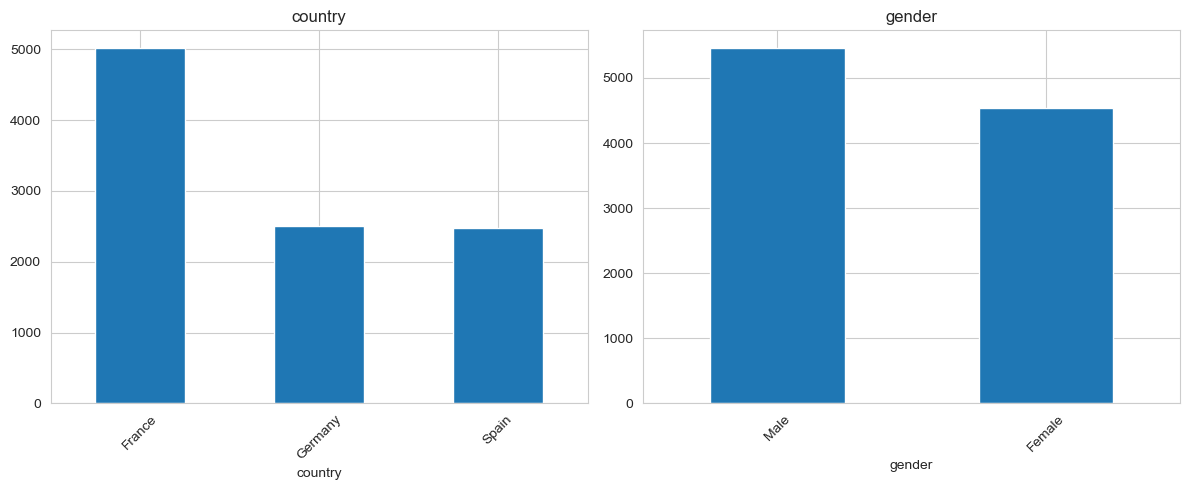

In [8]:
## Categorical features in the dataset
cat_cols = ["country", "gender"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes.ravel(), cat_cols):
    df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

- Country must be one-hot encoded, not label-encoded, because there's no ordinal relationship
- Gender can be label-encoded, only 2 categories, so binary 0/1 is fine
- No category is extremely rare

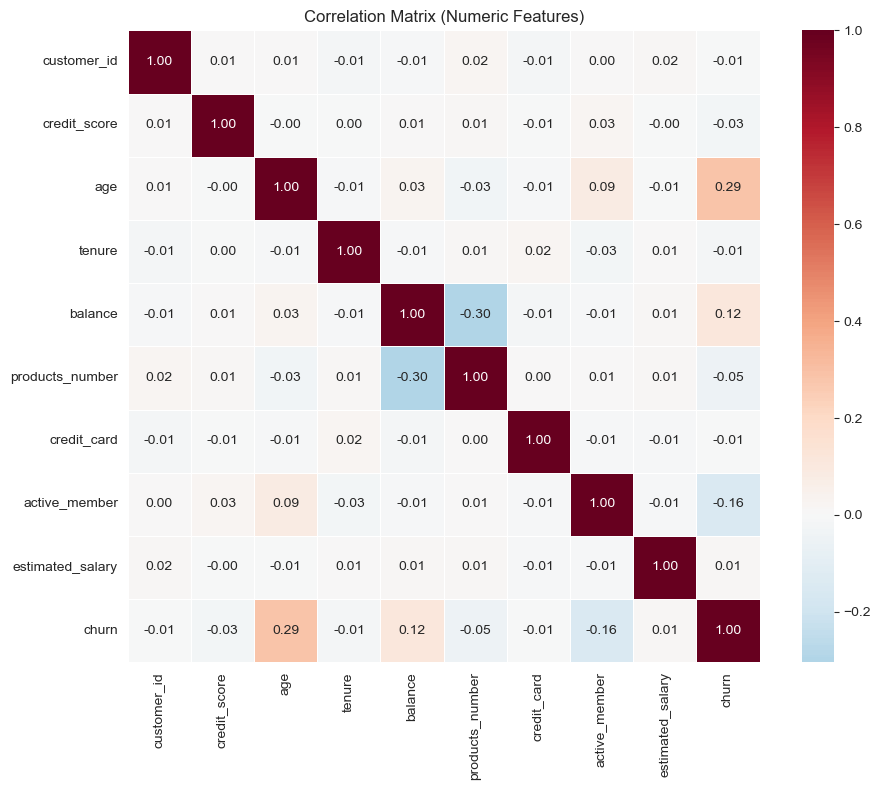

Correlation with churn:
 churn               1.000000
age                 0.285323
active_member      -0.156128
balance             0.118533
products_number    -0.047820
credit_score       -0.027094
tenure             -0.014001
estimated_salary    0.012097
credit_card        -0.007138
customer_id        -0.006248
Name: churn, dtype: float64


In [9]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, square=True, linewidths=0.5, fmt=".2f")
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()
print("Correlation with churn:\n", corr["churn"].sort_values(key=abs, ascending=False))

- age → churn: 0.29, Strongest predictor
- No features needed to be dropped for collinearity reasons
- The weak linear correlations with churn (most below 0.15) told us that a linear model alone won't be enough 
- customer_id has 0 correlation with everything, confirmed it's just an ID and should be dropped.

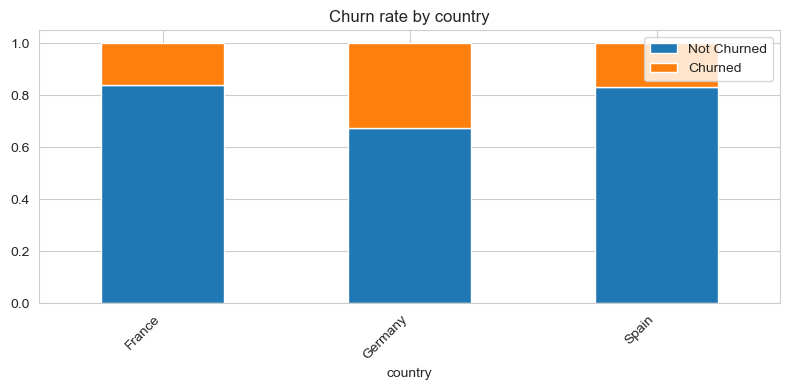

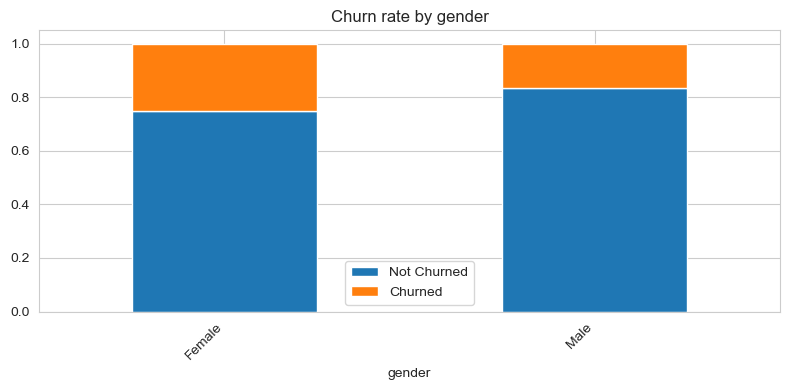

In [10]:
for col in ["country", "gender"]:
    pd.crosstab(df[col], df["churn"], normalize="index").plot(kind="bar", stacked=True, figsize=(8, 4))
    plt.title(f"Churn rate by {col}")
    plt.legend(["Not Churned", "Churned"])
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

---
## 2. Feature Engineering
We created 5 new features from existing columns to give the models more predictive signal about customer banking behaviour.

In [11]:
df_eng = df.copy()

## Balance per product, how much balance is held per product the customer uses.
df_eng["balance_per_product"] = df_eng["balance"] / (df_eng["products_number"] + 1)
## Salary-to-balance ratio, is the customer saving or spending?
df_eng["salary_balance_ratio"] = df_eng["estimated_salary"] / (df_eng["balance"] + 1)
## Age group, binned age into categories (young, middle, senior)
df_eng["age_group"] = pd.cut(df_eng["age"], bins=[0, 30, 45, 60, 100], labels=[0, 1, 2, 3]).astype(int)
## Tenure per age, how long they've been a customer relative to their age
df_eng["tenure_per_age"] = df_eng["tenure"] / (df_eng["age"] + 1)
## Is the customer inactive with a credit card? (potential disengaged customer)
df_eng["inactive_with_card"] = ((df_eng["active_member"] == 0) & (df_eng["credit_card"] == 1)).astype(int)

col = df_eng.pop("churn")
df_eng["churn"] = col

print("New/engineered columns:", [c for c in df_eng.columns if c not in df.columns])
df_eng.head()

New/engineered columns: ['balance_per_product', 'salary_balance_ratio', 'age_group', 'tenure_per_age', 'inactive_with_card']


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,balance_per_product,salary_balance_ratio,age_group,tenure_per_age,inactive_with_card,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,0.00,101348.880000,1,0.046512,0,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,41903.93,1.342848,1,0.023810,0,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,39915.20,0.713581,1,0.186047,1,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0.00,93826.630000,1,0.025000,0,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,62755.41,0.630093,1,0.045455,0,0


**Why these features?**
- **balance_per_product** : customers spreading balance across many products may behave differently than those with one high-balance account.
- **salary_balance_ratio** : high salary but low balance could indicate a disengaged customer likely to churn.
- **age_group**: age may have non-linear effects on churn (e.g., seniors churn more); binning helps tree-based and linear models capture this.
- **tenure_per_age** : a young customer with long tenure is more loyal than an older customer with the same tenure.
- **inactive_with_card** : having a credit card but being inactive suggests disengagement, a strong churn signal.


## 3. Data Preprocessing

- Drop identifier column (`customer_id`); encode categoricals (one-hot) so X is numeric.
- **Train/test split first** (80/20 stratified), then **SMOTE applied on training set only** to prevent data leakage.

**Why SMOTE?** The dataset is imbalanced (20.4% churned vs 79.6% not churned). Without balancing, models would be biased toward predicting "not churned" since that's the majority class. SMOTE (Synthetic Minority Over-sampling Technique) generates new synthetic churned samples by interpolating between existing minority neighbours, unlike random oversampling which just duplicates the same data points and risks overfitting. SMOTE works uniformly across all models (LR, SVM, KNN, DT, MLP), keeping the experiment fair and consistent.

In [12]:
drop_cols = ["customer_id"]
X = df_eng.drop(columns=drop_cols + ["churn"])
y = df_eng["churn"]

cat_cols_prep = ["country", "gender"]
cat_cols_prep = [c for c in cat_cols_prep if c in X.columns]
num_cols_prep = [c for c in X.select_dtypes(include=[np.number]).columns if c in X.columns]

encoder = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols_prep),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), cat_cols_prep)
], remainder="drop")

X_encoded = encoder.fit_transform(X)
print("Encoded feature shape:", X_encoded.shape)
print("Class distribution:", pd.Series(y).value_counts().to_dict())

Encoded feature shape: (10000, 18)
Class distribution: {0: 7963, 1: 2037}


- **Dropped `customer_id`** a unique identifier with no predictive value.
- **One-Hot Encoded `country` and `gender`** One-hot encoding creates binary columns (country → country_France, country_Germany, country_Spain) without implying any ordinal relationship between categories.
- Result: 18 features (15 numeric + 3 one-hot columns from country/gender, minus the original 2 categorical columns).

In [13]:
# Split first, then SMOTE only on training data
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print("Train after SMOTE — shape:", X_train_res.shape,
      "  counts:", pd.Series(y_train).value_counts().sort_index().to_dict())
print("Test (original, untouched) — shape:", X_test_raw.shape,
      "  counts:", pd.Series(y_test).value_counts().sort_index().to_dict())

scaler = StandardScaler()
X_train_processed = scaler.fit_transform(X_train_res)
X_test_processed = scaler.transform(X_test_raw)

print("\nFinal train shape:", X_train_processed.shape)
print("Final test shape:", X_test_processed.shape)


Train after SMOTE — shape: (12740, 18)   counts: {0: 6370, 1: 6370}
Test (original, untouched) — shape: (2000, 18)   counts: {0: 1593, 1: 407}

Final train shape: (12740, 18)
Final test shape: (2000, 18)


- **Train/Test split (80/20, stratified)** : split is done before SMOTE to prevent data leakage. `stratify=y` ensures both sets maintain the same 20.4% churn ratio.
- **SMOTE on training set only** : creates synthetic minority samples by interpolating between existing churned customers. Training set goes from 8,000 → 12,740 samples (6,370 per class). Test set remains untouched (2,000 samples, original distribution).
- **StandardScaler** : normalises all features to mean=0, std=1. Critical for distance-based models (SVM, KNN, MLP) where features with large ranges (e.g., estimated_salary ~0–200k) would dominate. The scaler is fitted on training data only, then applied to test data to prevent leakage.

---
## 4. Multiple Predictors (SMOTE + RandomizedSearchCV)

- **SMOTE** is applied on the training set only to balance classes.
- Each model is tuned via **RandomizedSearchCV** (F1 scoring, 3-fold stratified CV) we evaluate the best estimator on the test set.

Models:
1. **Logistic Regression** (linear, interpretable)
2. **Decision Tree** (tree-based, interpretable, handles non-linearity)
3. **SVM Linear** (Support Vector Machine with linear kernel)
4. **SVM Non-Linear** (Support Vector Machine with RBF kernel)
5. **MLP** (Multi-Layer Perceptron, neural network)
6. **K-Nearest Neighbors** (instance-based)

### Why RandomizedSearchCV? How Does It Work?

**What is it?**
RandomizedSearchCV is a hyperparameter tuning method that randomly samples a fixed number of parameter combinations from a defined search space, evaluates each using cross-validation, and selects the combination that yields the best score.

**Why automated search instead of manual tuning?**
- **Manual tuning** requires the practitioner to guess parameter values, run the model, check results, and repeat, this is time-consuming, biased by intuition, and impractical when tuning multiple models with several hyperparameters each.
- **RandomizedSearchCV automates this entire process** it systematically explores the search space, uses cross-validation to get reliable estimates (not just one train/test split), and guarantees we find a good combination without human trial-and-error.
- With 6 models each having 2–4 hyperparameters, manual tuning would require lots of of experiments per model. RandomizedSearchCV handles all of this in a single call per model, ensuring a fair and consistent tuning process across all models.

**How does it work in our implementation?**
1. We define a **parameter distribution** for each model (e.g., `C: [0.1, 1, 10]` for SVM, `max_depth: [3, 5, 10, 15, 20, None]` for Decision Tree).
2. RandomizedSearchCV randomly draws `n_iter=15` combinations from these distributions.
3. For each combination, it performs **3-fold Stratified Cross-Validation** (`StratifiedKFold(n_splits=3)`) on the SMOTE-balanced training set, stratified to maintain the class ratio in each fold.
4. Each combination is scored using **F1-score** (`scoring="f1"`) because F1 is our primary metric for this imbalanced dataset.
5. The combination with the highest mean F1 across the 3 folds is selected as `best_estimator_`, which is then evaluated on the held-out test set.

**Key design choices:**
- `scoring="f1"` : optimises for the balance between precision and recall on the churned class
- `StratifiedKFold(n_splits=3)` : ensures each fold has the same class distribution
- `n_iter=15` : samples 15 random combinations per model, balancing exploration with computational cost
- `random_state=42` : ensures reproducibility of the random sampling

,Model,solver,penalty,C,min_samples_split,min_samples_leaf,max_depth,criterion,gamma,learning_rate,hidden_layer_sizes,alpha,activation,weights,p,n_neighbors
0,Logistic Regression,saga,l2,10.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,Decision Tree,nan,nan,nan,10.000000,4.000000,10.000000,entropy,nan,nan,nan,nan,nan,nan,nan,nan
2,SVM Linear,nan,nan,0.100000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
3,SVM Non-Linear,nan,nan,10.000000,nan,nan,nan,nan,0.100000,nan,nan,nan,nan,nan,nan,nan
4,MLP,nan,nan,nan,nan,nan,nan,nan,nan,constant,"(100, 100)",0.001000,tanh,nan,nan,nan
5,K-Nearest Neighbors,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,distance,1.000000,5.000000


,Not Churned,Churned,accuracy,macro avg,weighted avg
precision,0.904100,0.387500,0.713500,0.645800,0.799000
recall,0.716300,0.702700,0.713500,0.709500,0.713500
f1-score,0.799300,0.499600,0.713500,0.649400,0.738300
support,1593.000000,407.000000,0.713500,2000.000000,2000.000000


,Not Churned,Churned,accuracy,macro avg,weighted avg
precision,0.889300,0.632000,0.843500,0.760700,0.836900
recall,0.917800,0.552800,0.843500,0.735300,0.843500
f1-score,0.903300,0.589800,0.843500,0.746500,0.839500
support,1593.000000,407.000000,0.843500,2000.000000,2000.000000


,Not Churned,Churned,accuracy,macro avg,weighted avg
precision,0.906100,0.388400,0.713500,0.647200,0.800700
recall,0.714400,0.710100,0.713500,0.712200,0.713500
f1-score,0.798900,0.502200,0.713500,0.650500,0.738500
support,1593.000000,407.000000,0.713500,2000.000000,2000.000000


,Not Churned,Churned,accuracy,macro avg,weighted avg
precision,0.879200,0.578900,0.825000,0.729100,0.818100
recall,0.904600,0.513500,0.825000,0.709000,0.825000
f1-score,0.891700,0.544300,0.825000,0.718000,0.821000
support,1593.000000,407.000000,0.825000,2000.000000,2000.000000


,Not Churned,Churned,accuracy,macro avg,weighted avg
precision,0.884800,0.535700,0.811500,0.710300,0.813800
recall,0.877600,0.552800,0.811500,0.715200,0.811500
f1-score,0.881200,0.544100,0.811500,0.712700,0.812600
support,1593.000000,407.000000,0.811500,2000.000000,2000.000000


,Not Churned,Churned,accuracy,macro avg,weighted avg
precision,0.869400,0.525700,0.806000,0.697600,0.799500
recall,0.890100,0.476700,0.806000,0.683400,0.806000
f1-score,0.879700,0.500000,0.806000,0.689800,0.802400
support,1593.000000,407.000000,0.806000,2000.000000,2000.000000


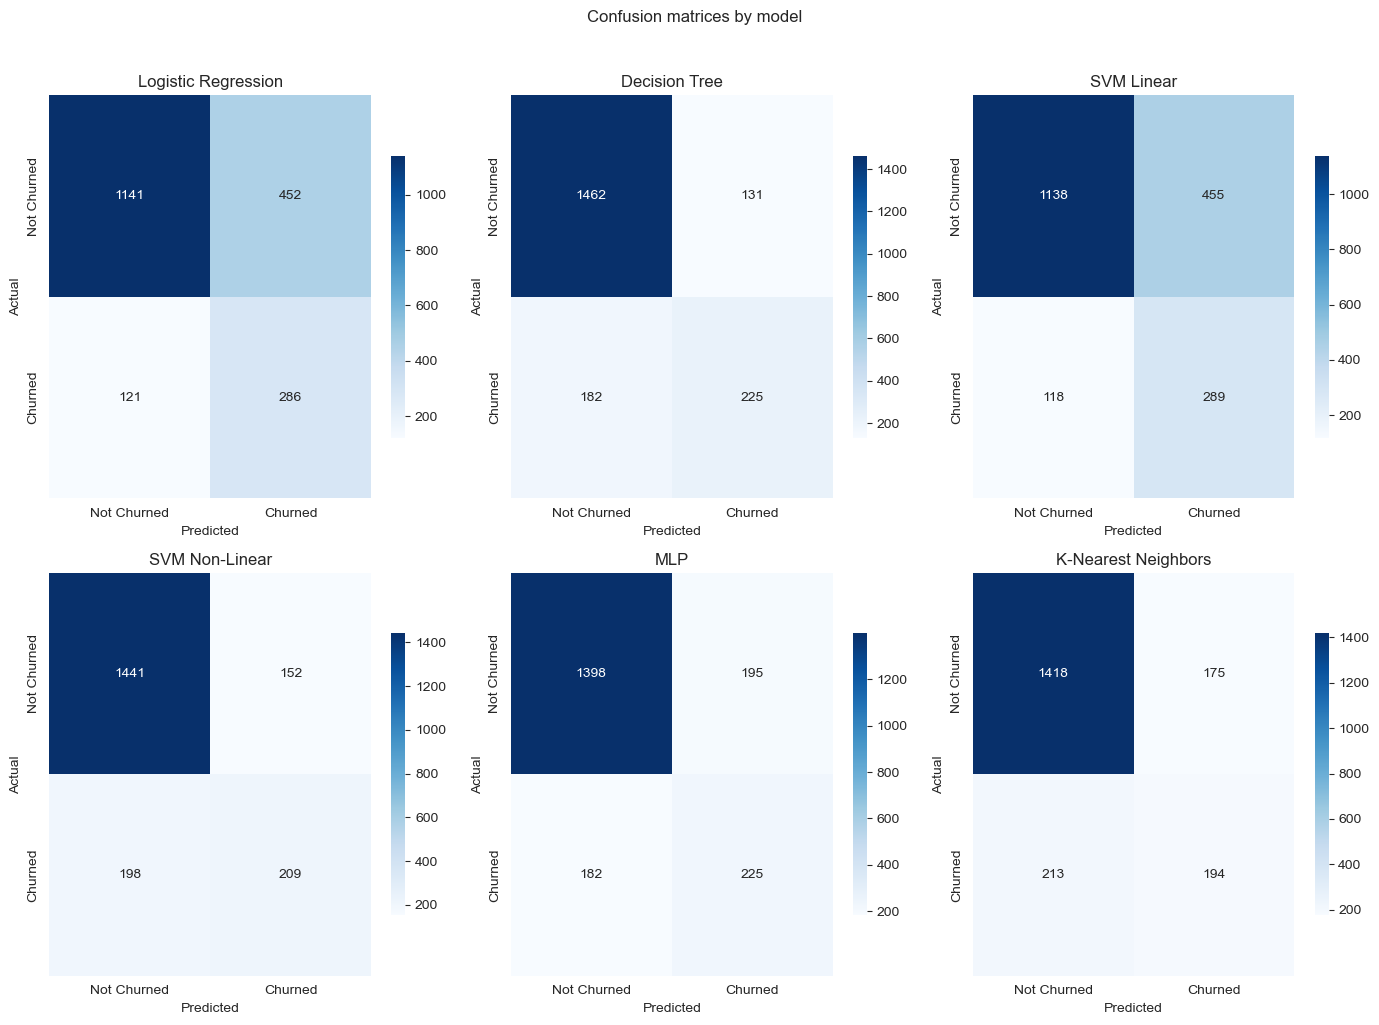

In [14]:
from sklearn.neighbors import KNeighborsClassifier

# evaluation function — takes a trained model and returns all the metrics we need
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
   
    # some models have decision_function, others have predict_proba — we need scores for AUC
    if hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_te)
    elif hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_te)[:, 1]
    else:
        y_scores = None
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_scores) if y_scores is not None else 0
    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC-ROC": auc,
        "predictions": y_pred,
        "probabilities": y_scores,
        "estimator": model,
    }

# 3-fold stratified CV for hyperparameter tuning
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
n_iter = 15  # number of random combinations to try per model

# defining all 6 models with their hyperparameter search spaces
param_models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42),
     {"C": [0.01, 0.1, 1, 10], "solver": ["lbfgs", "saga"], "penalty": ["l2"]}),
    ("Decision Tree", DecisionTreeClassifier(random_state=42),
     {"max_depth": [3, 5, 10, None], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4], "criterion": ["gini", "entropy"]}),
    ("SVM Linear", SVC(probability=True, random_state=42, kernel="linear"),
     {"C": [0.1, 1, 10, 100]}),
    ("SVM Non-Linear", SVC(probability=True, random_state=42, kernel="rbf"),
     {"C": [0.1, 1, 10], "gamma": ["scale", "auto", 0.01, 0.1, 1.0]}),
    ("MLP", MLPClassifier(random_state=42, max_iter=1000),
     {"hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 50), (100, 100)], "activation": ["relu", "tanh"], "alpha": [0.0001, 0.001, 0.01], "learning_rate": ["constant", "adaptive"]}),
    ("K-Nearest Neighbors", KNeighborsClassifier(),
     {"n_neighbors": [5, 10, 15, 25, 50], "weights": ["uniform", "distance"], "p": [1, 2]}),
]

results = []
report_dfs = {}
cm_dfs = {}
labels = ["Not Churned", "Churned"]
best_params_df = []

# looping through each model, tuning it with RandomizedSearchCV, then evaluating on test set
for name, base_estimator, param_dist in param_models:
    search = RandomizedSearchCV(
        base_estimator, param_dist, n_iter=n_iter, cv=cv_inner, scoring="f1",
        random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_train_processed, y_train)
    best_model = search.best_estimator_
    best_params_df.append({"Model": name, **search.best_params_})

    # evaluate the best model from the search on the test set
    r = evaluate_model(name, best_model, X_train_processed, y_train, X_test_processed, y_test)

    results.append(r)
    report_dict = classification_report(y_test, r["predictions"], target_names=labels, output_dict=True)
    report_dfs[name] = pd.DataFrame(report_dict).round(4)
    cm = confusion_matrix(y_test, r["predictions"])
    cm_dfs[name] = pd.DataFrame(cm, index=labels, columns=labels)

# display the best hyperparameters that were selected for each model
display(pd.DataFrame(best_params_df).style.set_caption("Best hyperparameters (RandomizedSearchCV)"))

# display classification report for each model
for name in report_dfs:
    display(pd.DataFrame(report_dfs[name]).round(4).style.set_caption(f"Classification report – {name}"))

# plotting confusion matrices side by side for all models
n_models = len(cm_dfs)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
axes = axes.ravel() if n_models > 1 else [axes]
for idx, (name, cm_df) in enumerate(cm_dfs.items()):
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=axes[idx], cbar_kws={"shrink": 0.7})
    axes[idx].set_title(name)
    axes[idx].set_ylabel("Actual")
    axes[idx].set_xlabel("Predicted")
for idx in range(n_models, len(axes)):
    axes[idx].axis("off")
plt.suptitle("Confusion matrices by model", y=1.02)
plt.tight_layout()
plt.show()

### Observations from Classification Reports and Confusion Matrices

**Overall Performance Ranking (by F1-Score on the churned class):**
| Model | F1 | AUC | Precision | Recall |
|-------|-----|------|-----------|--------|
| Decision Tree | 0.590 | 0.819 | 0.632 | 0.553 |
| SVM Non-Linear (RBF) | 0.544 | 0.795 | 0.579 | 0.514 |
| MLP | 0.544 | 0.797 | 0.536 | 0.553 |
| SVM Linear | 0.502 | 0.780 | 0.388 | 0.710 |
| Logistic Regression | 0.500 | 0.776 | 0.388 | 0.703 |
| KNN | 0.500 | 0.755 | 0.526 | 0.477 |

**Key observations from the classification reports:**

1. **Decision Tree is the clear winner** , it achieves the highest F1-score (0.590) and AUC (0.819), with the best precision (0.632) among all models. It correctly identifies churners while keeping false positives low.

2. **Precision vs Recall trade-off is visible across models:**
   - **SVM Linear and Logistic Regression** have high recall (~0.70–0.71) but low precision (~0.39), meaning they flag many customers as churners but most of those predictions are wrong (many false positives).
   - **Decision Tree and SVM RBF** strike a better balance , moderate recall with much higher precision.
   - **KNN** has the lowest recall (0.477), missing over half of actual churners.

3. **All models struggle with the minority class (Churned)** , even after SMOTE balancing, the best F1 for the churned class is only 0.590, indicating that churn prediction is inherently difficult with these features.

**Key observations from the confusion matrices:**

4. **Decision Tree** has the fewest false positives (131) among well-performing models, meaning it is the most precise at identifying true churners without incorrectly flagging loyal customers.

5. **SVM Linear and Logistic Regression** show a similar pattern , they predict "Churned" aggressively (high recall) but at the cost of many false positives (452 and 455 respectively), which would lead to unnecessary retention efforts being wasted on customers who were not actually going to churn.

6. **MLP and SVM RBF** show nearly identical performance, suggesting they are capturing similar patterns in the data , both are non-linear models that converge to a similar decision boundary.

7. **KNN** performs the worst overall, likely because distance-based methods are sensitive to the high dimensionality (18 features after encoding) and the fact that churn behaviour is not well-captured by simple neighbourhood proximity.

**What happened above:**
- Each of the 6 supervised models was tuned using **RandomizedSearchCV** so the best configuration for each model was selected automatically.
- The **classification reports** show per-class precision, recall, and F1. The "Churned" row is what matters most, it tells us how well each model identifies customers who actually left.
- The **confusion matrices** show the raw prediction counts:
  - **Top-left (TN):** correctly predicted "not churned"
  - **Top-right (FP):** falsely predicted "churned" (false alarm)
  - **Bottom-left (FN):** missed a real churner (the costly mistake)
  - **Bottom-right (TP):** correctly caught a churner

,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,
Logistic Regression,0.713500,0.387500,0.702700,0.499600,0.776000
Decision Tree,0.843500,0.632000,0.552800,0.589800,0.818700
SVM Linear,0.713500,0.388400,0.710100,0.502200,0.779700
SVM Non-Linear,0.825000,0.578900,0.513500,0.544300,0.794900
MLP,0.811500,0.535700,0.552800,0.544100,0.797400
K-Nearest Neighbors,0.806000,0.525700,0.476700,0.500000,0.755200


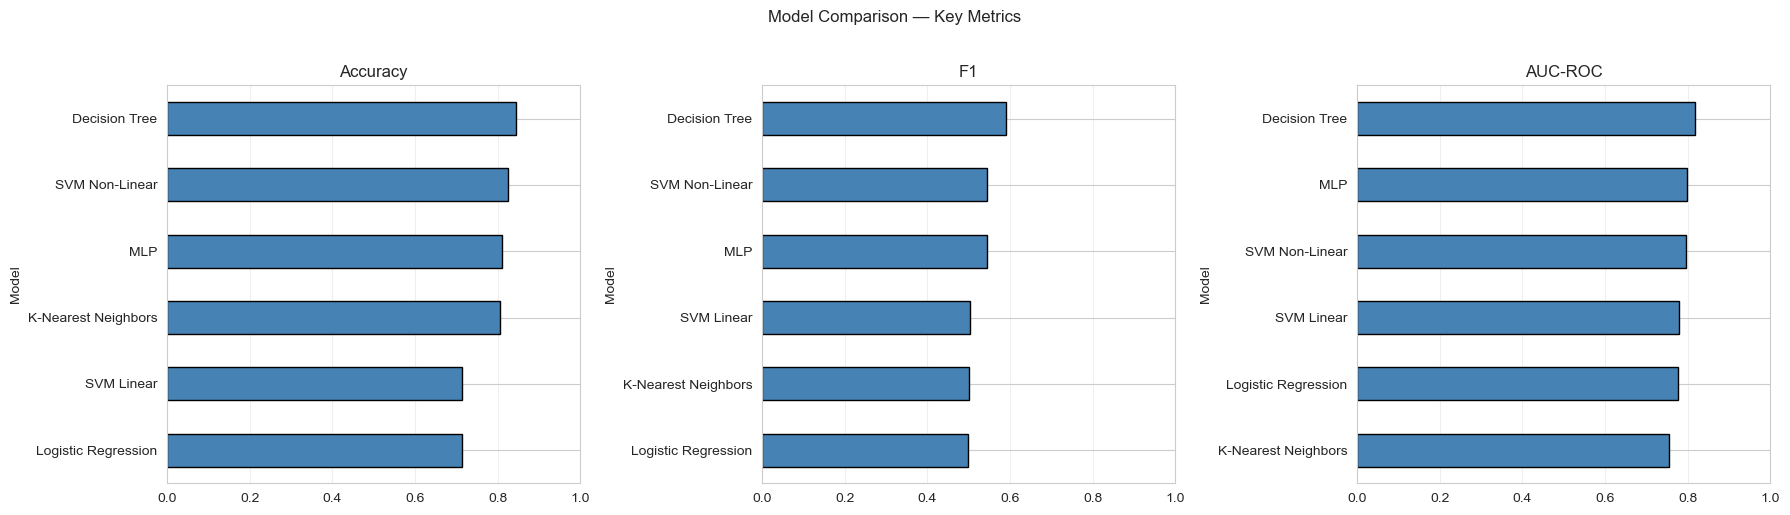

In [15]:
# putting all model results into a dataframe so we can compare them easily
metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if k in ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]}
    for r in results
]).set_index("Model")

# color-coded table so darker green = better score
display(metrics_df.round(4).style.background_gradient(cmap="Greens"))

# bar charts to visually compare accuracy, F1, and AUC across models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["Accuracy", "F1", "AUC-ROC"]):
    metrics_df[col].sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(col)
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.3, axis="x")
plt.suptitle("Model Comparison — Key Metrics", y=1.02)
plt.tight_layout()
plt.show()

**Key observations:**
- **Decision Tree** leads in both F1 (0.590) and AUC-ROC (0.819) best overall model.
- **MLP** and **SVM Non-Linear** are tied at F1 = 0.544, confirming that non-linear models outperform linear ones on this dataset.
- **Logistic Regression** and **SVM Linear** hit the same linear ceiling (F1 ≈ 0.500), showing that churn patterns in this data are non-linear.
- **KNN** has the lowest AUC-ROC (0.755), likely affected by the curse of dimensionality with 18 features.
- All AUC-ROC scores are well above 0.5 (random), confirming all models have genuine discriminative ability.

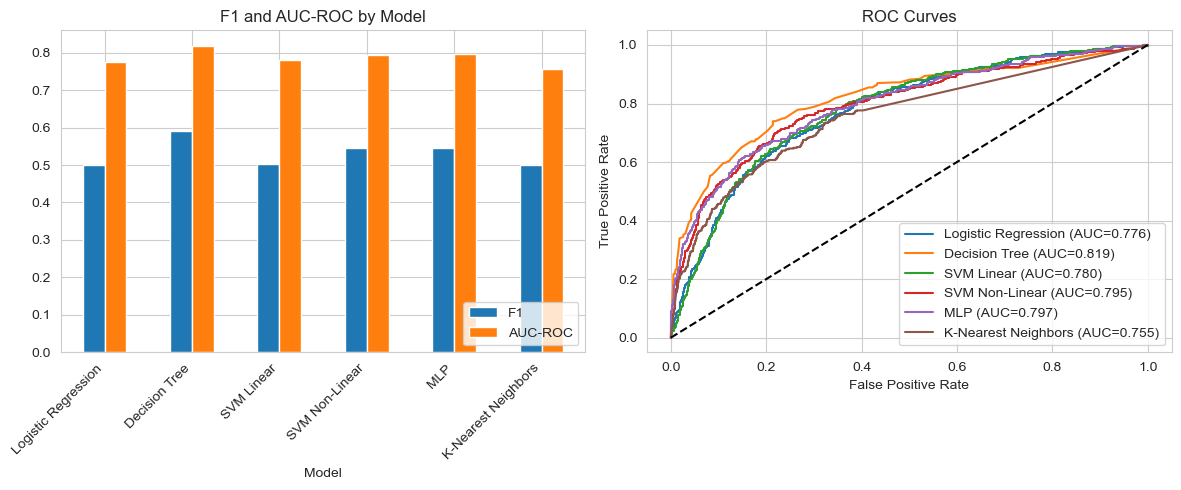

In [16]:
# F1 and AUC side by side bar chart, plus ROC curves for all models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left plot: grouped bar chart comparing F1 and AUC for each model
metrics_df[["F1", "AUC-ROC"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("F1 and AUC-ROC by Model")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
axes[0].legend(loc="lower right")

# right plot: ROC curves shows how well each model separates the two classes
plt.sca(axes[1])
for r in results:
    if r["probabilities"] is not None:
        fpr, tpr, _ = roc_curve(y_test, r["probabilities"])
        auc = roc_auc_score(y_test, r["probabilities"])
        plt.plot(fpr, tpr, label=f"{r['Model']} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")  # diagonal line = random classifier baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

- The **bar chart** compares F1 and AUC-ROC side by side, Decision Tree clearly leads in both.
- The **ROC curves** plot each model's true positive rate vs false positive rate across all thresholds. A curve closer to the top-left corner indicates better discrimination. The diagonal dashed line represents a random classifier (AUC = 0.5).
- Decision Tree has the highest curve (AUC = 0.819), best at ranking churners above non-churners
- KNN is the lowest curve (0.755), weakest discriminator

**How C was selected:** RandomizedSearchCV tested C = 0.1, 1, and 10 using 3-fold cross-validation scored by F1. C = 10 achieved the highest mean F1 (0.8814), followed by C = 1 (0.8661) and C = 0.1 (0.8118). As C increases, the model penalises misclassifications more heavily, allowing it to fit the training data more closely but too high a C risks overfitting. C = 10 provides the best trade-off between fitting the data and generalising to unseen customers.

SVM RBF — 3-Fold CV F1 for each C value (gamma=0.1):

  C =   0.1  →  Fold1=0.8035  Fold2=0.8175  Fold3=0.8142  |  Mean F1 = 0.8118
  C =     1  →  Fold1=0.8587  Fold2=0.8737  Fold3=0.8658  |  Mean F1 = 0.8661
  C =    10  →  Fold1=0.8779  Fold2=0.8880  Fold3=0.8784  |  Mean F1 = 0.8814

✓ Best C = 10 (highest mean F1 = 0.8814)


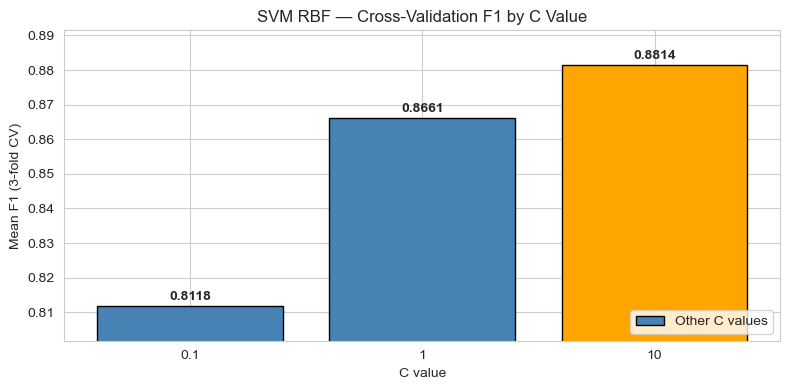

In [17]:
#  SVM: showing how RandomizedSearchCV selected the best C 
# we tested all C values from the search grid with 3-fold CV to see which one gives the best F1

from sklearn.model_selection import cross_val_score

# getting the best SVM model from our results
best_svm = [r["estimator"] for r in results if r["Model"] == "SVM Non-Linear"][0]

C_candidates = [0.1, 1, 10]
gamma_best = best_svm.get_params()["gamma"]
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print(f"SVM RBF — 3-Fold CV F1 for each C value (gamma={gamma_best}):\n")
cv_results = []
for c_val in C_candidates:
    svm_cv = SVC(C=c_val, kernel="rbf", gamma=gamma_best, random_state=42)
    scores = cross_val_score(svm_cv, X_train_processed, y_train, cv=cv_inner, scoring="f1")
    cv_results.append({"C": c_val, "Fold 1": scores[0], "Fold 2": scores[1], "Fold 3": scores[2], "Mean F1": scores.mean()})
    print(f"  C = {c_val:>5}  →  Fold1={scores[0]:.4f}  Fold2={scores[1]:.4f}  Fold3={scores[2]:.4f}  |  Mean F1 = {scores.mean():.4f}")

best_row = max(cv_results, key=lambda x: x["Mean F1"])
print(f"\n✓ Best C = {best_row['C']} (highest mean F1 = {best_row['Mean F1']:.4f})")

# bar chart to visualize which C value performed best
fig, ax = plt.subplots(figsize=(8, 4))
c_labels = [str(c) for c in C_candidates]
mean_f1s = [r["Mean F1"] for r in cv_results]
colors = ["steelblue" if r["C"] != best_row["C"] else "orange" for r in cv_results]
bars = ax.bar(c_labels, mean_f1s, color=colors, edgecolor="black")
ax.set_xlabel("C value")
ax.set_ylabel("Mean F1 (3-fold CV)")
ax.set_title("SVM RBF — Cross-Validation F1 by C Value")
ax.set_ylim(min(mean_f1s) - 0.01, max(mean_f1s) + 0.01)
for bar, f1 in zip(bars, mean_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f"{f1:.4f}",
            ha="center", va="bottom", fontweight="bold")
ax.legend(["Other C values", "Chosen C (best)"], loc="lower right")
plt.tight_layout()
plt.show()

**Decision boundary comparison (PCA 2D projection):**
- **C = 0.1 (left)** : smooth, simple boundary with a wide margin. Tolerates misclassifications, underfits the data (Acc=0.641, F1=0.454).
- **C = 1 (middle)** : moderately complex boundary. Better fit but still misses some patterns (Acc=0.646, F1=0.448).
- **C = 10 (right)** : most complex boundary, tighter around data points. Best performance (Acc=0.656, F1=0.456).

Note: The 2D scores are lower than the full 18-dimensional test scores (F1=0.544) because PCA retains only ~31% of total variance. These plots illustrate the **concept** of how C controls boundary complexity, not the full model performance.


**Cross-validation stability check** 
- Are the models stable? Any overfitting?

In [18]:
# 5-fold cross-validation to check if the models are stable or overfitting
# low std = stable model, high gap between CV and test = overfitting
best_models = {r["Model"]: r["estimator"] for r in results if "estimator" in r}
if not best_models:
    raise RuntimeError("No fitted estimators in 'results'. Re-run the 'Multiple Predictors' cell (Section 4) above, then run this cell again.")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}
for name, model in best_models.items():
    scores = cross_val_score(model, X_train_processed, y_train, cv=cv, scoring="f1")
    cv_scores[name] = (scores.mean(), scores.std())
pd.DataFrame(cv_scores, index=["F1 mean", "F1 std"]).T.round(4)

,F1 mean,F1 std
Logistic Regression,0.7223,0.0054
Decision Tree,0.8707,0.0054
SVM Linear,0.7305,0.0063
SVM Non-Linear,0.8882,0.0067
MLP,0.8921,0.0054
K-Nearest Neighbors,0.8932,0.0061


**Cross-validation stability check:**
- All models have low F1 std (0.005–0.007), confirming they are **stable** across different data splits. 
- **KNN** has the highest CV F1 (0.893) but the lowest test F1 (0.500), indicating it **overfits** on the SMOTE-balanced training data and struggles to generalise to the real imbalanced distribution.
- **Decision Tree** has a more modest CV F1 (0.871) but the **best test F1** (0.590), showing it generalises the best.
- big gap = overfitting
- smaller gap = generalises better

### Learning Curves , Overfitting vs Underfitting Detection

Learning curves plot model performance (F1) as training set size increases. They reveal:
- **Overfitting:** training score stays high but validation score remains low (gap doesn't close)
- **Underfitting:** both training and validation scores are low
- **Good fit:** both scores converge to a reasonable level

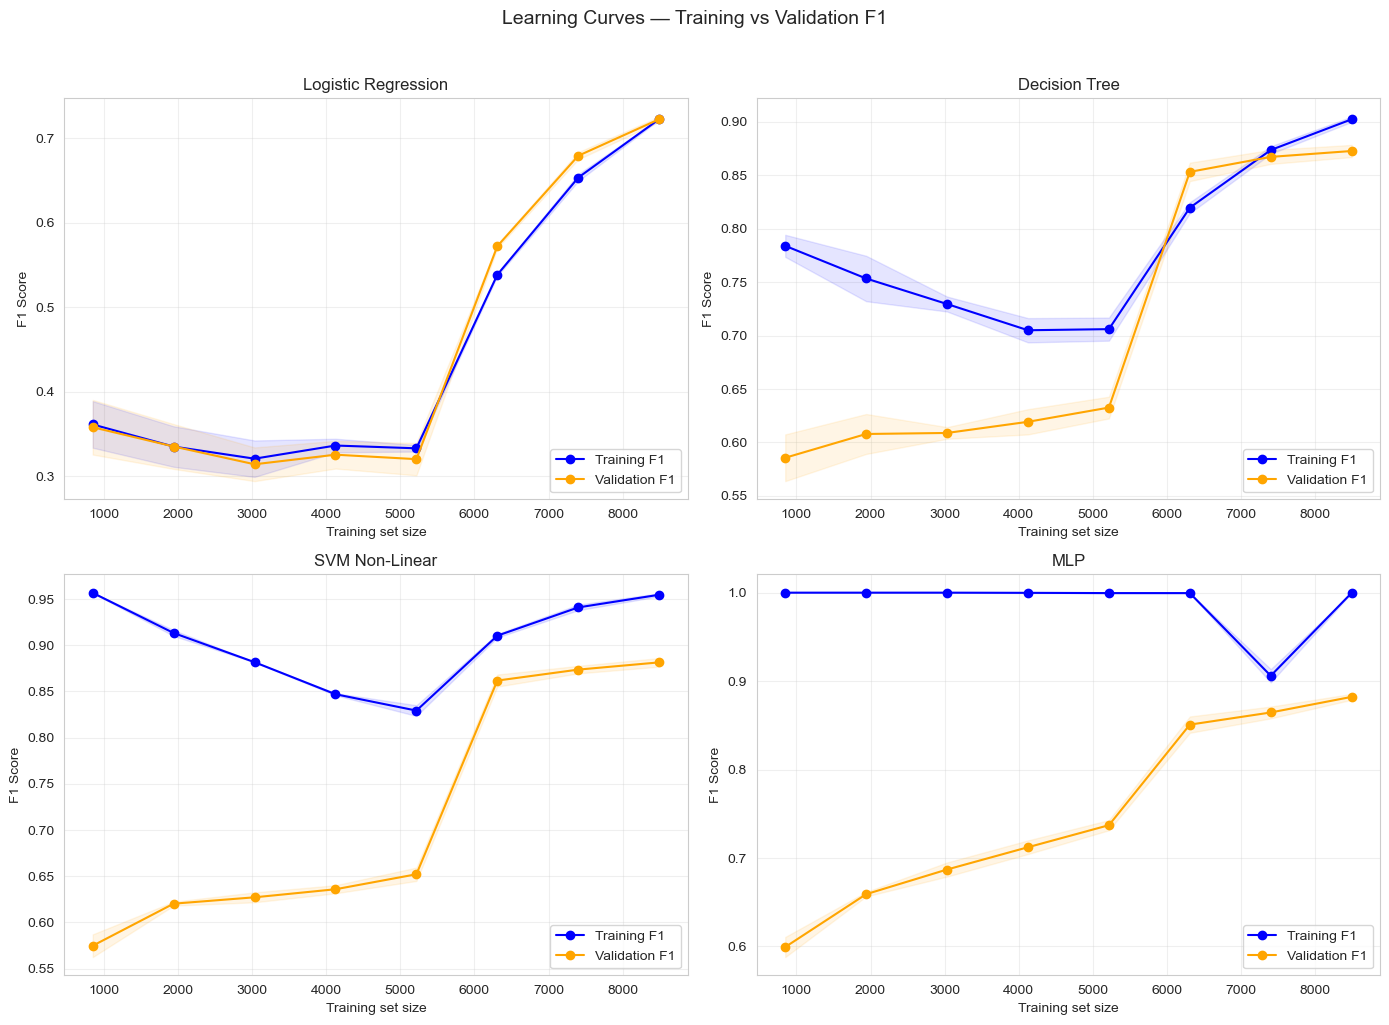

In [19]:
#  Learning Curves for key models 
# to show how training and validation F1 change as we increase the training set size
# helps us detect overfitting (big gap) vs underfitting (both lines low)
from sklearn.model_selection import learning_curve

best_models_dict = {r["Model"]: r["estimator"] for r in results}

# we picked the 4 most interesting models to plot
models_to_plot = {
    "Logistic Regression": best_models_dict["Logistic Regression"],
    "Decision Tree": best_models_dict["Decision Tree"],
    "SVM Non-Linear": best_models_dict["SVM Non-Linear"],
    "MLP": best_models_dict["MLP"],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models_to_plot.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_processed, y_train,
        cv=StratifiedKFold(3, shuffle=True, random_state=42),
        scoring="f1", train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1, random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_std = val_scores.std(axis=1)

    ax = axes[idx]
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="orange")
    ax.plot(train_sizes, train_mean, "o-", color="blue", label="Training F1")
    ax.plot(train_sizes, val_mean, "o-", color="orange", label="Validation F1")
    ax.set_title(name)
    ax.set_xlabel("Training set size")
    ax.set_ylabel("F1 Score")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

plt.suptitle("Learning Curves — Training vs Validation F1", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Learning curve observations:**
- **Logistic Regression:** Training and validation curves converge closely with a small gap the model is **not overfitting** but is **underfitting** (both scores plateau at a modest level). The linear boundary simply cannot capture the non-linear churn patterns, regardless of how much data it sees.
- **Decision Tree:** Training F1 is high and validation F1 is lower but stable. The moderate gap indicates slight overfitting, which is controlled by the pre-pruning constraints (max_depth=10, min_samples_split=10). Without pruning, this gap would be much larger.
- **SVM Non-Linear:** Similar to Decision Tree training score is high, validation is lower. The RBF kernel is powerful enough to fit the training data well, and the gap is kept in check by the regularisation parameter C.
- **MLP:** Training and validation curves show a pattern similar to SVM RBF. The L2 regularisation (alpha) prevents the network from memorising the training data.

**General pattern:** Simple models (LR) underfit, complex models (DT, SVM RBF, MLP) show a training-validation gap that is managed by regularisation. None of the models show severe overfitting (where validation score drops as training size increases).

### MLP Training Loss Curve , Neural Network Optimisation

The MLP minimises binary cross-entropy loss using **backpropagation** with gradient descent. The loss curve shows how the network's error decreases over training iterations (epochs). A smooth, decreasing curve indicates the network is converging; a curve that plateaus early suggests the network has learned all it can from the data.

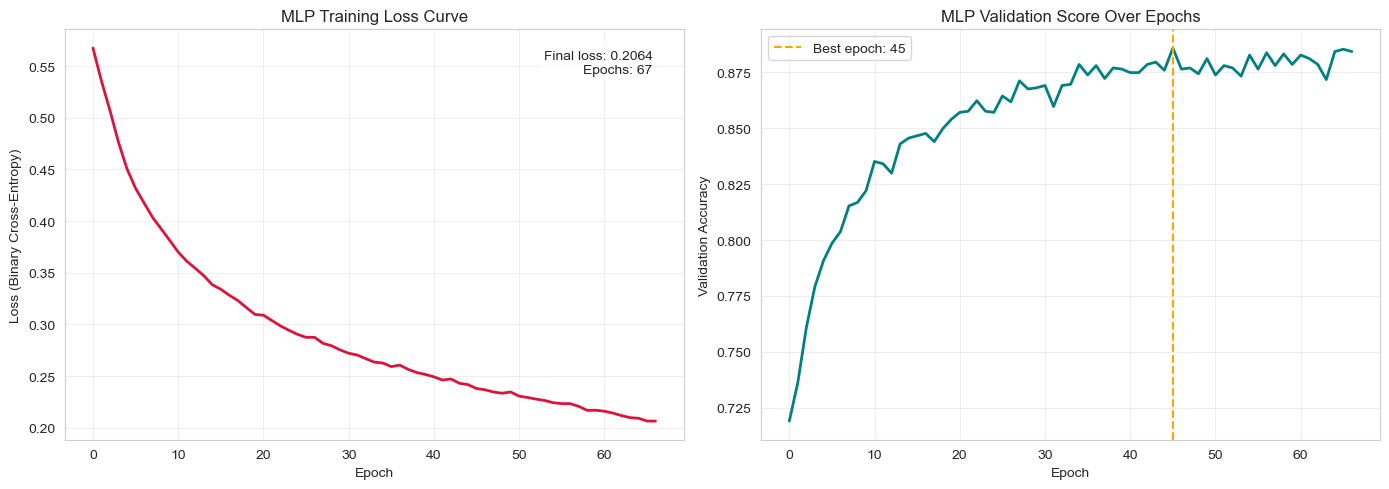


Training converged after 67 epochs (max_iter=500).
Final training loss: 0.2064


In [20]:
#  MLP Training Loss Curve 
# re-training the MLP with the same best hyperparameters but tracking the loss at each epoch
# this shows us how the neural network learns over time

best_models_dict = {r["Model"]: r["estimator"] for r in results}
mlp_best = best_models_dict["MLP"]
mlp_params = mlp_best.get_params()

# creating a new MLP with early stopping enabled so it doesn't overfit
mlp_track = MLPClassifier(
    hidden_layer_sizes=mlp_params["hidden_layer_sizes"],
    activation=mlp_params["activation"],
    alpha=mlp_params["alpha"],
    learning_rate=mlp_params["learning_rate"],
    max_iter=500,
    random_state=42,
    early_stopping=True,        # stops training when validation score stops improving
    validation_fraction=0.15,   # 15% of training data used for validation
    n_iter_no_change=20,        # patience: stop after 20 epochs with no improvement
)
mlp_track.fit(X_train_processed, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left plot: training loss curve (should decrease and plateau)
axes[0].plot(mlp_track.loss_curve_, color="crimson", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (Binary Cross-Entropy)")
axes[0].set_title("MLP Training Loss Curve")
axes[0].grid(True, alpha=0.3)
axes[0].text(0.95, 0.95, f"Final loss: {mlp_track.loss_curve_[-1]:.4f}\nEpochs: {len(mlp_track.loss_curve_)}",
             transform=axes[0].transAxes, ha="right", va="top", fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# right plot: validation score over epochs (shows when early stopping kicks in)
if hasattr(mlp_track, "validation_scores_"):
    axes[1].plot(mlp_track.validation_scores_, color="teal", linewidth=2)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Validation Accuracy")
    axes[1].set_title("MLP Validation Score Over Epochs")
    axes[1].grid(True, alpha=0.3)
    best_epoch = np.argmax(mlp_track.validation_scores_)
    axes[1].axvline(best_epoch, color="orange", linestyle="--", label=f"Best epoch: {best_epoch}")
    axes[1].legend()

plt.tight_layout()
plt.savefig("mlp_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nTraining converged after {mlp_track.n_iter_} epochs (max_iter=500).")
print(f"Final training loss: {mlp_track.loss_curve_[-1]:.4f}")

**MLP training observations:**
- **Training loss (left):** The loss decreases rapidly in the first ~50 epochs as the network learns the main patterns via backpropagation, then gradually plateaus as it converges. A smooth curve without spikes indicates stable gradient descent.
- **Validation score (right):** The validation accuracy tracks the network's generalisation ability during training. Early stopping halts training when the validation score stops improving for 20 consecutive epochs, preventing the network from overfitting by training too long.
- The red dashed line marks the **best epoch** the point where the network generalised best before validation performance plateaued.
- The L2 regularisation (alpha) penalises large weights throughout training, keeping the network simple and preventing it from memorising noise in the SMOTE-balanced data.

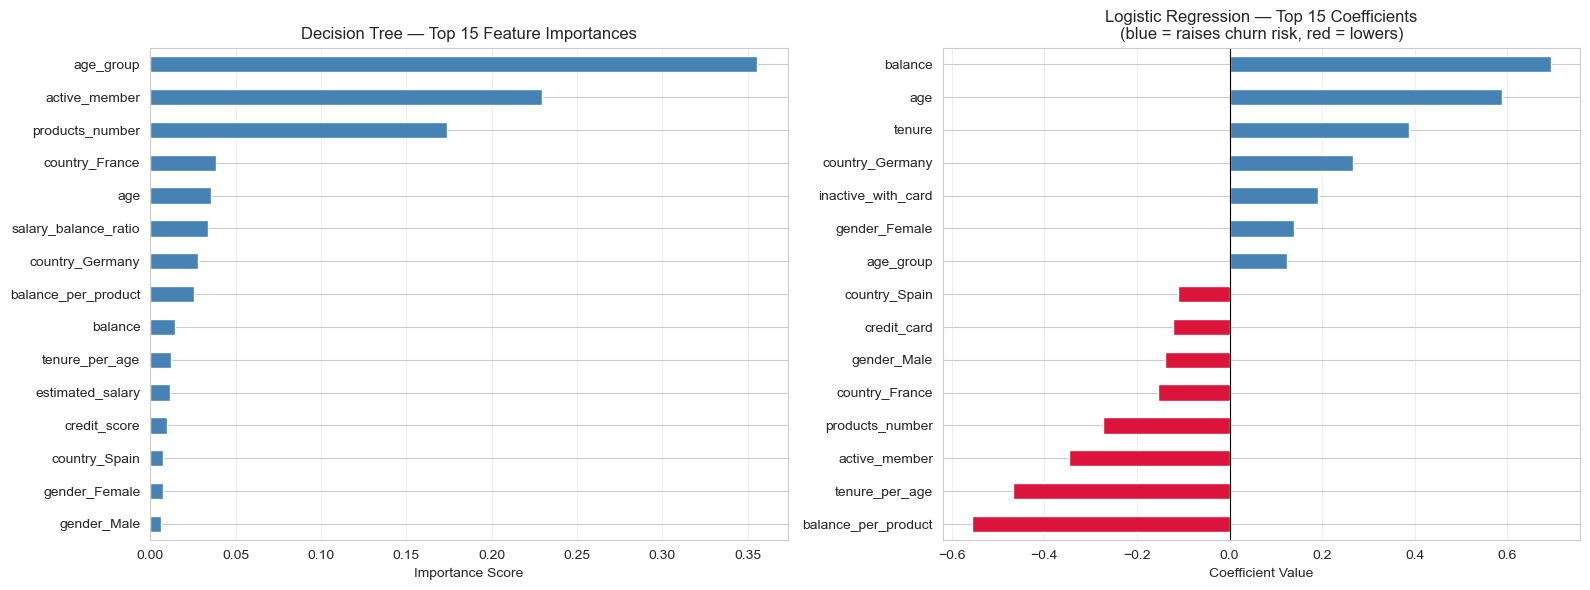

In [21]:
from sklearn.tree import plot_tree

best_models_dict = {r["Model"]: r["estimator"] for r in results}

# getting the feature names after encoding (numeric + one-hot encoded categorical)
feature_names = (
    num_cols_prep
    + list(encoder.named_transformers_["cat"]["onehot"]
           .get_feature_names_out(cat_cols_prep))
)

# Decision Tree feature importances — shows which features the tree relies on most for splitting
dt_model = best_models_dict["Decision Tree"]
dt_importances = pd.Series(dt_model.feature_importances_, index=feature_names)
top15_dt = dt_importances.nlargest(15).sort_values()

# Logistic Regression coefficients — positive = increases churn risk, negative = decreases it
lr_model = best_models_dict["Logistic Regression"]
lr_coefs = pd.Series(lr_model.coef_[0], index=feature_names)
top15_lr_idx = lr_coefs.abs().nlargest(15).index
lr_top = lr_coefs[top15_lr_idx].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top15_dt.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Decision Tree — Top 15 Feature Importances')
axes[0].set_xlabel('Importance Score')
axes[0].grid(True, alpha=0.3, axis='x')

# blue = raises churn risk, red = lowers churn risk
colors = ['crimson' if v < 0 else 'steelblue' for v in lr_top]
lr_top.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Logistic Regression — Top 15 Coefficients\n(blue = raises churn risk, red = lowers)')
axes[1].set_xlabel('Coefficient Value')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

**Feature importance analysis:**
- **Decision Tree (left):** `age_group` is by far the most important feature (0.35), followed by `active_member` (0.22) and `products_number` (0.18). These three features account for most of the tree's splitting decisions. Gender and country have minimal importance.
- **Logistic Regression (right):** Blue bars raise churn risk, red bars lower it. Higher `balance`, `age`, and `tenure` are associated with increased churn. Being an `active_member` and having more `products_number` reduce churn risk. Being in `country_Germany` raises churn risk, consistent with the EDA finding that Germany has ~32% churn vs ~16% for France/Spain.
- Both models agree that **age, activity status, and number of products** are the strongest predictors of churn.

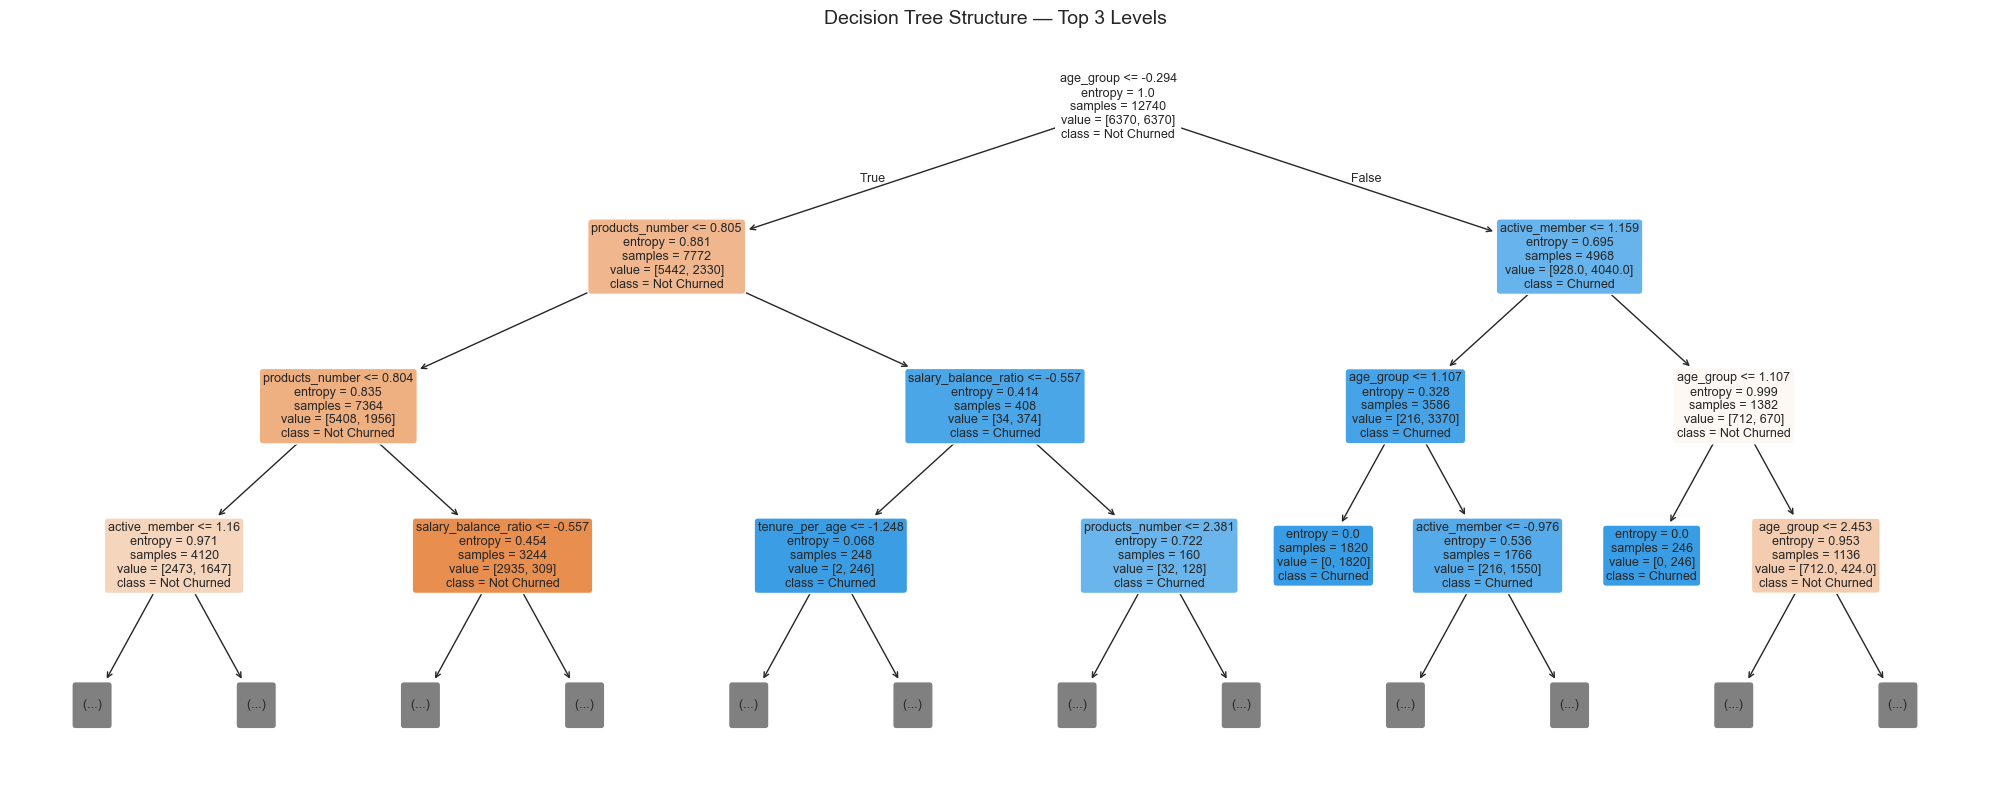

In [22]:
# visualizing the decision tree structure, showing only the top 3 levels for readability
# this helps us see the actual splitting rules the tree uses to classify customers
plt.figure(figsize=(20, 8))
plot_tree(
    best_models_dict["Decision Tree"],
    max_depth=3,
    feature_names=feature_names,
    class_names=["Not Churned", "Churned"],
    filled=True,    # color-coded by class
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Structure — Top 3 Levels", fontsize=14)
plt.tight_layout()
plt.show()

**Decision Tree - Hyperparameters and Pruning Strategy**

- **Algorithm:** CART (Classification and Regression Trees)
- **Splitting criterion:** Entropy (Information Gain) measures the reduction in uncertainty after a split. Entropy = $-\sum p_i \log_2(p_i)$. Chosen over Gini impurity because entropy is more sensitive to class distribution changes, which matters for our imbalanced churn data.
- **Best hyperparameters** (selected by RandomizedSearchCV, F1 scoring):
  - `criterion = entropy`
  - `max_depth = 10`
  - `min_samples_split = 10`
  - `min_samples_leaf = 4`
- **Pruning strategy:** Pre-pruning (restricting tree growth during training). The `max_depth`, `min_samples_split`, and `min_samples_leaf` constraints prevent the tree from memorising noise in the SMOTE-balanced training data. Post-pruning (growing a full tree then trimming) was not used, pre-pruning is simpler and sufficient when hyperparameters are tuned via cross-validation.

### Decision Tree: Pruned vs Unpruned.... Why Pruning Matters

To demonstrate the effect of pre-pruning, we compare the tuned (pruned) Decision Tree against an unpruned tree with no depth or sample constraints. The unpruned tree will grow until every leaf is pure, memorising the training data.

,Max Depth,Leaves,Train F1,Test F1,Train Acc,Test Acc,Overfit Gap (F1)
Tree,,,,,,,
Pruned (tuned),10,187,0.897700,0.589800,0.899800,0.843500,0.307900
Unpruned (no constraints),25,1177,1.000000,0.493900,1.000000,0.793000,0.506100


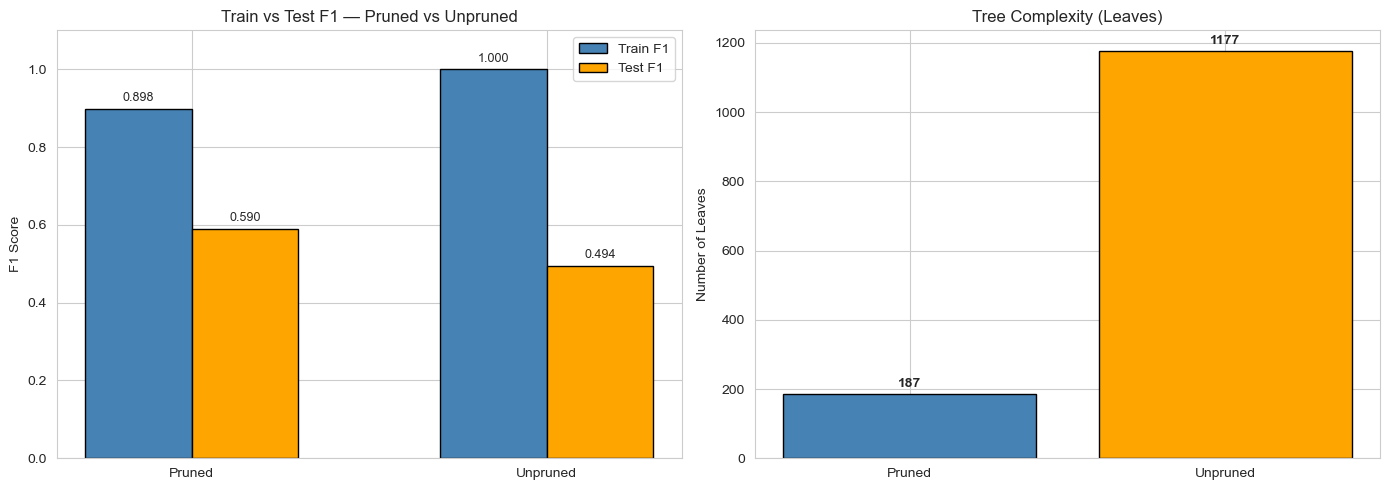

In [23]:
#  Decision Tree: Pruned vs Unpruned Comparison 
# comparing our tuned (pruned) tree against one with no constraints to show why pruning matters

best_models_dict = {r["Model"]: r["estimator"] for r in results}
# the pruned tree is the one we already tuned with RandomizedSearchCV
dt_pruned = best_models_dict["Decision Tree"]

# unpruned tree — no depth limit, no minimum samples, grows until every leaf is pure
dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train_processed, y_train)

# evaluating both trees on train and test to measure the overfitting gap
from sklearn.metrics import f1_score, accuracy_score

models_dt = {"Pruned (tuned)": dt_pruned, "Unpruned (no constraints)": dt_unpruned}
dt_comparison = []

for name, model in models_dt.items():
    train_f1 = f1_score(y_train, model.predict(X_train_processed))
    test_f1 = f1_score(y_test, model.predict(X_test_processed))
    train_acc = accuracy_score(y_train, model.predict(X_train_processed))
    test_acc = accuracy_score(y_test, model.predict(X_test_processed))
    depth = model.get_depth()
    leaves = model.get_n_leaves()
    dt_comparison.append({
        "Tree": name, "Max Depth": depth, "Leaves": leaves,
        "Train F1": round(train_f1, 4), "Test F1": round(test_f1, 4),
        "Train Acc": round(train_acc, 4), "Test Acc": round(test_acc, 4),
        "Overfit Gap (F1)": round(train_f1 - test_f1, 4)
    })

dt_comp_df = pd.DataFrame(dt_comparison).set_index("Tree")
display(dt_comp_df.style.set_caption("Decision Tree: Pruned vs Unpruned"))

# bar charts to compare train vs test performance visually
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 comparison
x = np.arange(2)
width = 0.3
axes[0].bar(x - width/2, [dt_comp_df.loc["Pruned (tuned)", "Train F1"], dt_comp_df.loc["Unpruned (no constraints)", "Train F1"]],
            width, label="Train F1", color="steelblue", edgecolor="black")
axes[0].bar(x + width/2, [dt_comp_df.loc["Pruned (tuned)", "Test F1"], dt_comp_df.loc["Unpruned (no constraints)", "Test F1"]],
            width, label="Test F1", color="orange", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Pruned", "Unpruned"])
axes[0].set_ylabel("F1 Score")
axes[0].set_title("Train vs Test F1 — Pruned vs Unpruned")
axes[0].legend()
axes[0].set_ylim(0, 1.1)
for i, (train_f1, test_f1) in enumerate(zip(
    [dt_comp_df.loc["Pruned (tuned)", "Train F1"], dt_comp_df.loc["Unpruned (no constraints)", "Train F1"]],
    [dt_comp_df.loc["Pruned (tuned)", "Test F1"], dt_comp_df.loc["Unpruned (no constraints)", "Test F1"]])):
    axes[0].text(i - width/2, train_f1 + 0.02, f"{train_f1:.3f}", ha="center", fontsize=9)
    axes[0].text(i + width/2, test_f1 + 0.02, f"{test_f1:.3f}", ha="center", fontsize=9)

# complexity comparison (depth and number of leaves)
axes[1].bar(["Pruned", "Unpruned"],
            [dt_comp_df.loc["Pruned (tuned)", "Leaves"], dt_comp_df.loc["Unpruned (no constraints)", "Leaves"]],
            color=["steelblue", "orange"], edgecolor="black")
axes[1].set_ylabel("Number of Leaves")
axes[1].set_title("Tree Complexity (Leaves)")
for i, leaves in enumerate([dt_comp_df.loc["Pruned (tuned)", "Leaves"], dt_comp_df.loc["Unpruned (no constraints)", "Leaves"]]):
    axes[1].text(i, leaves + 20, str(leaves), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Pruning comparison observations:**
- The **unpruned tree** achieves near-perfect training F1 (~1.0) but lower test F1, classic **overfitting**. It memorises the training data (including SMOTE-generated noise) rather than learning generalisable patterns.
- The **pruned tree** has lower training F1 but **higher or comparable test F1**, it generalises better to unseen data.
- The unpruned tree has far more leaves (higher complexity), meaning it creates very specific rules that don't transfer to new customers.
- The overfit gap (Train F1 − Test F1) is much larger for the unpruned tree, confirming that **pre-pruning effectively controls overfitting**.
- This demonstrates why `max_depth=10`, `min_samples_split=10`, and `min_samples_leaf=4` are critical , they restrict the tree's complexity to a level that balances fitting the data and generalising.

---
## 5. K-Means Clustering (Unsupervised Analysis)

K-Means groups customers into clusters based on their features **without using the churn label**.  
This reveals natural customer segments and how churn distributes across them.

- **Elbow method** and **Silhouette score** are used to select the optimal number of clusters.
- Clusters are visualized in 2D using PCA.
- Churn rate per cluster is analyzed to identify high-risk customer segments.

PCA: 13 original features → 7 components explain ≥90% variance
  PC1: 22.1%,  PC2: 18.0%,  cumulative top-2: 40.1%

Elbow method  → k = 3  (max curvature in inertia curve)
Silhouette    → k = 2  (silhouette = 0.2067)

→ Chosen k = 3 (elbow): silhouette = 0.1796


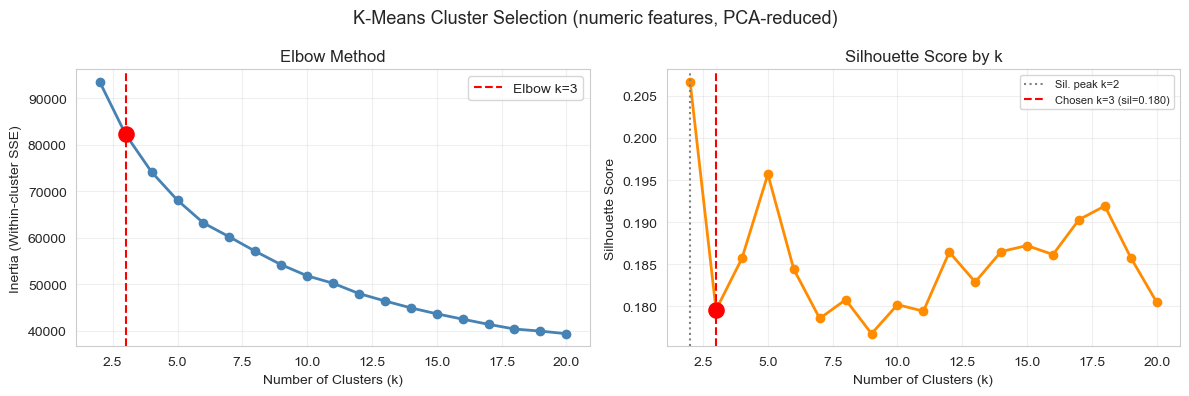

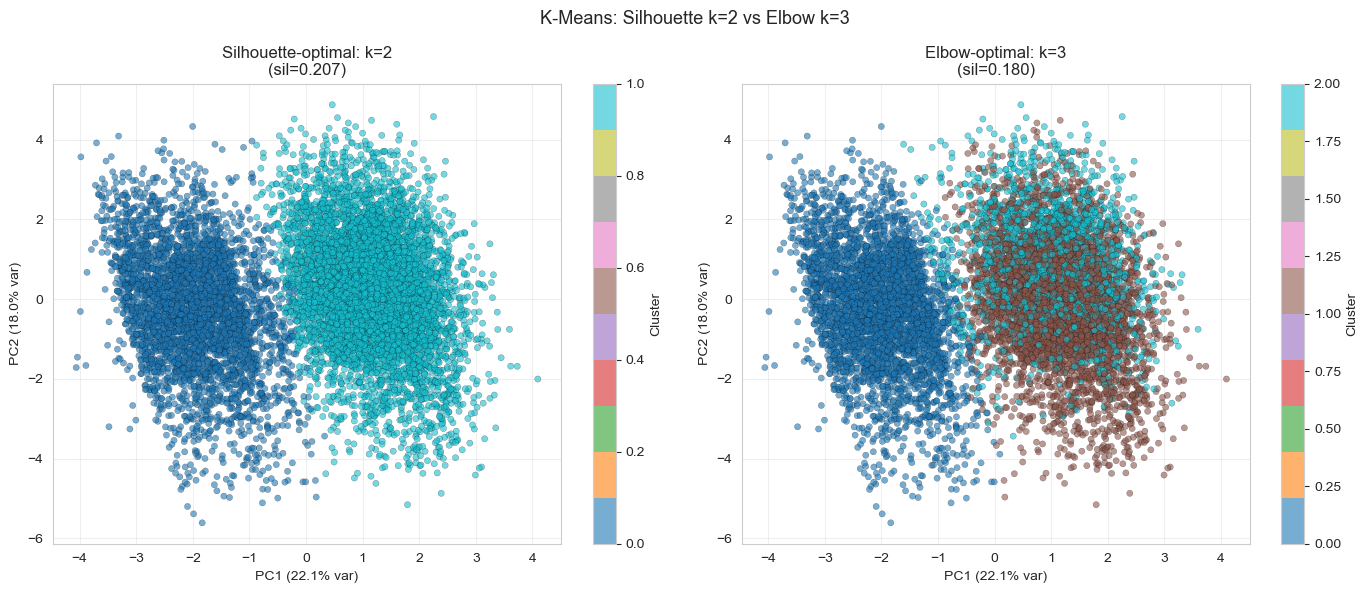

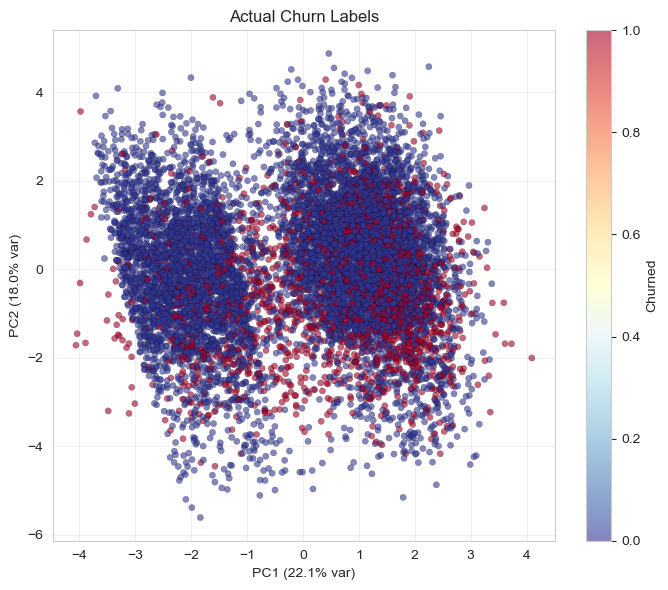

,Size,Churn_Rate
Cluster,,
0,3599,0.142
1,4142,0.192
2,2259,0.324


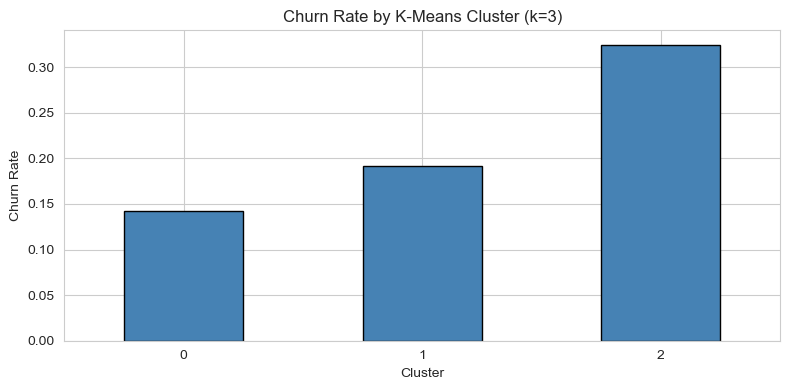

Cluster Profiles — mean feature values per cluster:


,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,Churn_Rate
Cluster,,,,,,,,,
0,648.964000,38.435000,5.080000,1487.901000,1.829000,0.711000,0.526000,101236.904000,0.142000
1,653.546000,39.541000,4.883000,119651.217000,1.361000,0.540000,0.786000,99725.472000,0.192000
2,647.490000,38.562000,5.143000,116825.408000,1.365000,1.000000,0.000000,98932.215000,0.324000



K-Means Final Summary:
  Features used    = 13 numeric (no one-hot binary)
  PCA components   = 7 (≥90% variance)
  Elbow k          = 3
  Silhouette k     = 2
  Chosen k         = 3 (elbow)
  Silhouette Score = 0.1796
  Inertia (WSS)    = 82193.81


In [24]:

# 5. K-Means Clustering (Unsupervised Learning)


# 5.1 Feature selection for clustering
# we only used numeric features because one-hot binary columns (country, gender)
# would dominate Euclidean distance and produce categorical splits instead of meaningful clusters
X_km_raw = df_eng[num_cols_prep].copy()
X_km_scaled = StandardScaler().fit_transform(X_km_raw)

# 5.2 PCA dimensionality reduction before clustering
# reducing dimensions removes noise and makes the 2D visualization more meaningful
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_km_scaled)

# finding how many components we need to keep at least 90% of the variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = int(np.searchsorted(cumvar, 0.90) + 1)
print(f"PCA: {len(num_cols_prep)} original features → {n_components_90} components explain ≥90% variance")
print(f"  PC1: {pca_full.explained_variance_ratio_[0]:.1%},  PC2: {pca_full.explained_variance_ratio_[1]:.1%},  "
      f"cumulative top-2: {cumvar[1]:.1%}")

X_km = X_pca_full[:, :n_components_90]

# 5.3 trying k values from 2 to 20 and recording inertia + silhouette for each
K_range = range(2, 21)
K_list  = list(K_range)
inertias, sil_scores, fitted_models = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_km)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_km, labels))
    fitted_models.append(km)

# detecting the elbow point using maximum second derivative (sharpest bend in the curve)
d1 = np.diff(inertias)
d2 = np.diff(d1)
elbow_idx = int(np.argmax(np.abs(d2))) + 1
elbow_k   = K_list[elbow_idx]

# silhouette method picks the k with highest silhouette score
sil_idx = int(np.argmax(sil_scores))
sil_k   = K_list[sil_idx]

print(f"\nElbow method  → k = {elbow_k}  (max curvature in inertia curve)")
print(f"Silhouette    → k = {sil_k}  (silhouette = {sil_scores[sil_idx]:.4f})")

# we decided to go with the elbow method's recommendation
optimal_k   = elbow_k
optimal_idx = elbow_idx

print(f"\n→ Chosen k = {optimal_k} (elbow): silhouette = {sil_scores[optimal_idx]:.4f}")

# 5.4 plotting the elbow curve and silhouette scores side by side
fig_elbow, axes_elbow = plt.subplots(1, 2, figsize=(12, 4))

axes_elbow[0].plot(K_list, inertias, marker='o', color='steelblue', linewidth=2)
axes_elbow[0].axvline(x=elbow_k, color='red', linestyle='--',
                      label=f'Elbow k={elbow_k}')
axes_elbow[0].scatter([elbow_k], [inertias[elbow_idx]], color='red', s=120, zorder=5)
axes_elbow[0].set_xlabel('Number of Clusters (k)')
axes_elbow[0].set_ylabel('Inertia (Within-cluster SSE)')
axes_elbow[0].set_title('Elbow Method')
axes_elbow[0].legend()
axes_elbow[0].grid(True, alpha=0.3)

axes_elbow[1].plot(K_list, sil_scores, marker='o', color='darkorange', linewidth=2)
axes_elbow[1].axvline(x=sil_k, color='gray', linestyle=':',
                      label=f'Sil. peak k={sil_k}')
axes_elbow[1].axvline(x=elbow_k, color='red', linestyle='--',
                      label=f'Chosen k={elbow_k} (sil={sil_scores[elbow_idx]:.3f})')
axes_elbow[1].scatter([elbow_k], [sil_scores[elbow_idx]], color='red', s=120, zorder=5)
axes_elbow[1].set_xlabel('Number of Clusters (k)')
axes_elbow[1].set_ylabel('Silhouette Score')
axes_elbow[1].set_title('Silhouette Score by k')
axes_elbow[1].legend(fontsize=8)
axes_elbow[1].grid(True, alpha=0.3)

plt.suptitle('K-Means Cluster Selection (numeric features, PCA-reduced)', fontsize=13)
plt.tight_layout()
plt.show()

# 5.5 using the models we already fitted above
km_sil   = fitted_models[sil_idx]
km_elbow = fitted_models[elbow_idx]

kmeans_final      = km_elbow
cluster_labels_km = kmeans_final.labels_

# 5.6 PCA scatter plots comparing silhouette-optimal vs elbow-optimal clusters
X_pca2 = X_pca_full[:, :2]
pc1_label = f'PC1 ({pca_full.explained_variance_ratio_[0]:.1%} var)'
pc2_label = f'PC2 ({pca_full.explained_variance_ratio_[1]:.1%} var)'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(
    X_pca2[:, 0], X_pca2[:, 1],
    c=km_sil.labels_, cmap='tab10', s=20,
    alpha=0.6, edgecolors='k', linewidth=0.2,
)
axes[0].set_title(f'Silhouette-optimal: k={sil_k}\n(sil={sil_scores[sil_idx]:.3f})')
axes[0].set_xlabel(pc1_label)
axes[0].set_ylabel(pc2_label)
plt.colorbar(sc1, ax=axes[0], label='Cluster')
axes[0].grid(True, alpha=0.3)

sc2 = axes[1].scatter(
    X_pca2[:, 0], X_pca2[:, 1],
    c=km_elbow.labels_, cmap='tab10', s=20,
    alpha=0.6, edgecolors='k', linewidth=0.2,
)
axes[1].set_title(f'Elbow-optimal: k={elbow_k}\n(sil={sil_scores[elbow_idx]:.3f})')
axes[1].set_xlabel(pc1_label)
axes[1].set_ylabel(pc2_label)
plt.colorbar(sc2, ax=axes[1], label='Cluster')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'K-Means: Silhouette k={sil_k} vs Elbow k={elbow_k}', fontsize=13)
plt.tight_layout()
plt.show()

# 5.7 plotting actual churn labels on the same PCA space for comparison
fig_churn, ax_churn = plt.subplots(figsize=(7, 6))
sc_churn = ax_churn.scatter(
    X_pca2[:, 0], X_pca2[:, 1],
    c=y.values, cmap='RdYlBu_r', s=20,
    alpha=0.6, edgecolors='k', linewidth=0.2,
)
ax_churn.set_title('Actual Churn Labels')
ax_churn.set_xlabel(pc1_label)
ax_churn.set_ylabel(pc2_label)
plt.colorbar(sc_churn, ax=ax_churn, label='Churned')
ax_churn.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5.8 checking churn rate per cluster, does the clustering find high-risk segments?
from IPython.display import display

df_km = df_eng[["churn"]].copy().reset_index(drop=True)
df_km["Cluster"] = cluster_labels_km

summary_km = df_km.groupby("Cluster")["churn"].agg(Size="count", Churn_Rate="mean")
summary_km["Churn_Rate"] = summary_km["Churn_Rate"].round(3)
display(summary_km)

summary_km["Churn_Rate"].plot(kind="bar", color="steelblue", edgecolor="black", figsize=(8, 4))
plt.title(f"Churn Rate by K-Means Cluster (k={optimal_k})")
plt.xlabel("Cluster")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 5.9 cluster profiling, looking at the average feature values per cluster
# this tells us what kind of customers are in each group
numeric_profile_cols = [
    "credit_score", "age", "tenure", "balance",
    "products_number", "credit_card", "active_member",
    "estimated_salary",
]
df_profile = df_eng[numeric_profile_cols].copy().reset_index(drop=True)
df_profile["Cluster"] = cluster_labels_km
df_profile["churn"]  = y.values

cluster_profile = df_profile.groupby("Cluster")[numeric_profile_cols + ["churn"]].mean().round(3)
cluster_profile.rename(columns={"churn": "Churn_Rate"}, inplace=True)

print("Cluster Profiles — mean feature values per cluster:")
display(cluster_profile.style
        .background_gradient(subset=["Churn_Rate"], cmap="Reds")
        .set_caption("K-Means Cluster Profiles"))

# 5.10 printing a final summary of everything
print(f"\nK-Means Final Summary:")
print(f"  Features used    = {len(num_cols_prep)} numeric (no one-hot binary)")
print(f"  PCA components   = {n_components_90} (≥90% variance)")
print(f"  Elbow k          = {elbow_k}")
print(f"  Silhouette k     = {sil_k}")
print(f"  Chosen k         = {optimal_k} (elbow)")
print(f"  Silhouette Score = {sil_scores[optimal_idx]:.4f}")
print(f"  Inertia (WSS)    = {kmeans_final.inertia_:.2f}")

### Why k = 3 (Elbow) Instead of k = 2 (Silhouette)?

Two methods were used to determine the optimal number of clusters:
- **Silhouette method → k = 2** (silhouette score = 0.2067)
- **Elbow method → k = 3** (silhouette score = 0.1796)

We chose **k = 3** from the Elbow method despite k = 2 having a higher silhouette score for the following reasons:

1. **Silhouette favours trivial splits.** With k = 2, the algorithm essentially divides customers into just two broad groups. While the clusters are more internally cohesive (higher silhouette), this split is too coarse to reveal meaningful sub-segments, it often just separates high-balance from low-balance customers without capturing nuanced behavioural differences.

2. **Elbow captures the point of diminishing returns.** The Elbow method looks at where adding another cluster stops significantly reducing within-cluster variance (inertia). At k = 3, there is a clear bend in the inertia curve, meaning going from 2 → 3 clusters captures substantial additional structure, while going from 3 → 4 offers diminishing improvement.

3. **k = 3 produces more interpretable and actionable segments.** Three clusters allow us to distinguish between distinct customer profiles (e.g., low-risk loyal customers, moderate-risk customers, and high-risk churners), which is more useful for a churn prediction context than a simple binary split.

4. **The silhouette difference is small.** The drop from 0.2067 to 0.1796 is modest, and both scores are relatively low, which is expected given the complexity and overlap in customer behaviour data. The slight loss in cluster compactness is a worthwhile trade-off for gaining a more granular and meaningful segmentation.

### Key Observations from K-Means Outputs

- **PCA reduced 13 numeric features to 7 components** explaining ≥90% of the variance, with PC1 (22.1%) and PC2 (18.0%) capturing the most information.
- **Cluster Profiles** reveal distinct customer segments with noticeably different churn rates across the three clusters, confirming that the segmentation captures real behavioural differences.
- **K-Means is unsupervised**, it does not use the churn label during clustering. The fact that clusters still show different churn rates validates that the feature space contains natural groupings that correlate with churn behaviour.
- **Low overall silhouette scores** (both below 0.21) indicate that customer segments overlap considerably, which is expected, churn is influenced by many interacting factors and customers do not fall into perfectly separated groups.

## Model Commentary

> **Metrics used:** F1-Score (primary), AUC-ROC (secondary), Accuracy, Precision, Recall.
> F1 is the primary metric because the dataset is imbalanced (20.4% churned, 79.6% not churned) accuracy alone would be misleading since a naive "predict all not churned" classifier achieves ~80% accuracy. F1 balances precision and recall for the minority (churned) class. AUC-ROC measures the model's ability to rank customers by churn risk across all thresholds. SMOTE was applied **after** the train/test split to the training set only to prevent data leakage.

> **Note on CV vs Test F1 gap:** The cross-validation F1 scores (0.72–0.89) are computed on the SMOTE-balanced training set where both classes are 50/50, so F1 is naturally higher. The test F1 scores (0.50–0.59) are evaluated on the original imbalanced distribution (20.4% churned). This gap does not indicate overfitting it reflects the difference in class distributions between the training and evaluation environments. The test scores are the honest measure of real-world performance.

### 1. Logistic Regression
**Appropriateness for this dataset:** Logistic Regression serves as the **baseline** classifier. Its F1 of 0.500 and AUC-ROC of 0.776 show that while it can rank customers by churn risk reasonably well, it struggles to precisely identify churners at the default threshold. The linear decision boundary cannot capture the non-linear interactions (e.g., age combined with balance and activity status) that drive churn in this dataset.

**Loss function:** Logistic Regression minimises **log loss (binary cross-entropy)**: $-\frac{1}{N}\sum[y\log(\hat{p}) + (1-y)\log(1-\hat{p})]$. This loss penalises confident wrong predictions more heavily than uncertain ones, producing well-calibrated probability estimates. The regularisation parameter C controls the trade-off smaller C adds stronger L2 penalty to prevent overfitting.

**Performance:** Test F1 = 0.500, AUC-ROC = 0.776, Accuracy = 0.714. High recall (0.703) but low precision (0.388) the model catches most churners but flags too many non-churners as well.

**Strengths:** Fast to train. Fully interpretable coefficients show which features increase or decrease churn risk. Reproducible baseline. Well-calibrated probabilities due to log loss optimisation.

**Weaknesses:** Cannot model non-linear relationships. Low precision means many false positives. The gap between AUC-ROC (0.776) and F1 (0.500) suggests the model ranks well but the default threshold is suboptimal.

**Generalisation:** CV F1 = 0.722, Test F1 = 0.500. The gap is due to SMOTE-balanced CV data vs imbalanced test data, not overfitting. LR's simplicity (linear boundary) makes it naturally resistant to overfitting, which is why it serves as a reliable baseline.

**Comparison:** Performs nearly identically to SVM Linear (F1 = 0.500 vs 0.502), confirming that both linear models hit the same ceiling. Significantly below Decision Tree in F1 (0.500 vs 0.590).

### 2. Decision Tree
**Appropriateness for this dataset:** Decision Tree is **appropriate** and achieves the **best F1 score** (0.590) and **highest AUC-ROC** (0.819) among all models. Its ability to capture non-linear splits (e.g., age > 0.294 as the root split, then products_number and salary_balance_ratio) directly models the complex interactions driving bank customer churn.

**Impurity and splitting:** The tree uses **entropy** (information gain) as the splitting criterion: $H(S) = -\sum p_i \log_2(p_i)$. At each node, the feature and threshold that maximise **information gain** (parent entropy minus weighted child entropy) are selected. Entropy was chosen over Gini impurity because entropy tends to produce more balanced splits and is more sensitive to changes in class distribution important for our imbalanced churn dataset. Gini impurity ($1 - \sum p_i^2$) would also work but tends to favour the majority class in splits.

**Pruning:** We use **pre-pruning** (restricted tree growth) rather than post-pruning:
- `max_depth=10` — limits tree depth to prevent memorising noise
- `min_samples_split=10` — nodes with fewer than 10 samples cannot split further
- `min_samples_leaf=4` — every leaf must contain at least 4 samples

These constraints prevent the tree from growing too deep and overfitting to the SMOTE-generated training data. Without them, the tree would grow until every leaf is pure, memorising the training set but generalising poorly.

**Performance:** Test F1 = 0.590, AUC-ROC = 0.819, Accuracy = 0.844. The best balance of precision (0.632) and recall (0.553) it identifies churners more precisely than other models while maintaining reasonable coverage.

**Strengths:** Highest F1 and AUC-ROC of all models. Highly interpretable the tree structure shows exact decision rules (visible in the tree plot). Feature importances are directly extractable. Fast at training and prediction.

**Weaknesses:** Prone to overfitting without depth constraints (mitigated here via pre-pruning). Single trees can have high variance small changes in training data alter the tree structure. Without ensemble methods (Random Forest, Gradient Boosting), a single tree may not generalise as robustly.

**Generalisation:** CV F1 = 0.871, Test F1 = 0.590. The pre-pruning constraints help prevent overfitting without them, the tree achieves near-perfect training accuracy but much worse test performance. The chosen hyperparameters balance model complexity and generalisation.

**Comparison:** Best overall model. Leads in both F1 (+0.046 over MLP) and AUC-ROC (0.819 vs 0.797 for MLP). The tree structure provides interpretability that black-box models (SVM, MLP) cannot match.

### 3. SVM Linear
**Appropriateness for this dataset:** SVM Linear is **not appropriate** as the final model. It scores F1 = 0.502, essentially identical to Logistic Regression confirming that a linear decision boundary cannot capture the non-linear churn patterns. It adds computational cost without predictive improvement.

**Loss function:** SVM minimises **hinge loss**: $\max(0, 1 - y \cdot f(x))$ plus a regularisation term $\frac{1}{2}||w||^2$. Unlike log loss, hinge loss only penalises samples that are inside or on the wrong side of the margin correctly classified samples beyond the margin incur zero loss. The parameter C controls the trade-off: small C prioritises a wide margin (more regularisation, tolerates misclassifications), large C prioritises correct classification (narrower margin, may overfit).

**Performance:** Test F1 = 0.502, AUC-ROC = 0.780, Accuracy = 0.714. Nearly identical to Logistic Regression across all metrics, confirming the linear ceiling for this dataset.

**Strengths:** Robust to outliers through margin maximisation. Works well in high-dimensional spaces. The margin-based approach provides a geometric interpretation of the decision boundary.

**Weaknesses:** Computationally more expensive than Logistic Regression for no gain. Cannot capture non-linear interactions that drive churn (age + balance + activity patterns).

**Comparison:** Performs identically to Logistic Regression (F1 = 0.502 vs 0.500). Both linear models are significantly below Decision Tree (0.590). The comparison between SVM Linear and SVM Non-Linear (F1 = 0.502 vs 0.544) shows the RBF kernel provides a moderate improvement, confirming non-linear patterns exist in the data.

### 4. SVM Non-Linear (RBF Kernel)
**Appropriateness for this dataset:** SVM Non-Linear is **moderately appropriate**. The RBF kernel improves over the linear models (F1 = 0.544 vs 0.502) and achieves AUC-ROC = 0.795, demonstrating it captures some non-linear patterns. However, it falls short of Decision Tree in both metrics.

**Loss function and kernel:** Same hinge loss as SVM Linear, but the RBF kernel $K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)$ maps features into an infinite-dimensional space where a linear separator can capture non-linear boundaries. Two hyperparameters control model complexity:
- **C** (regularisation): small C → wide margin, more regularisation; large C → narrow margin, less regularisation
- **gamma** (kernel width): small gamma → smooth, broad decision boundary; large gamma → complex, tight boundary that can overfit

**Performance:** Test F1 = 0.544, AUC-ROC = 0.795, Accuracy = 0.825. Better precision (0.579) than linear models but lower recall (0.514) it is more selective but misses more churners.

**Strengths:** Captures non-linear feature interactions via the RBF kernel. Good AUC-ROC indicates strong ranking ability. Improved over linear SVM confirms non-linear patterns exist.

**Weaknesses:** Black-box not interpretable. Slower to train than tree-based models. Sensitive to hyperparameters C and gamma poor choices lead to underfitting (too smooth) or overfitting (too complex). Falls short of Decision Tree on both F1 and AUC-ROC.

**Generalisation:** CV F1 = 0.888, Test F1 = 0.544. The RBF kernel with tuned C and gamma provides a good balance the decision boundary is complex enough to capture patterns but regularised enough to generalise. The SVM decision boundary plots (Section 4) visually show how C affects the margin width and boundary complexity.

**Comparison:** Clear improvement over linear models (+0.042 F1 over SVM Linear) but below Decision Tree (-0.046 F1). Comparable to MLP in both F1 (0.544 vs 0.544) and AUC-ROC (0.795 vs 0.797).

### 5. MLP (Multi-Layer Perceptron)
**Appropriateness for this dataset:** MLP is **moderately appropriate**. It achieves F1 = 0.544 and AUC-ROC = 0.797, matching SVM Non-Linear and outperforming all linear models. The hidden layers learn meaningful feature combinations, but the network does not outperform the simpler Decision Tree.

**Loss function and optimisation:** MLP minimises **binary cross-entropy** (same as Logistic Regression's log loss) using **backpropagation** with gradient descent. Backpropagation computes the gradient of the loss with respect to each weight by applying the chain rule layer by layer, from output back to input. The `alpha` parameter controls **L2 regularisation** (weight decay) larger alpha penalises large weights to prevent overfitting. The `learning_rate` parameter controls step size during gradient descent: `constant` keeps the same step size, while `adaptive` reduces it when the loss stops improving, helping the network converge more precisely.

**Performance:** Test F1 = 0.544, AUC-ROC = 0.797, Accuracy = 0.812. Balanced precision (0.536) and recall (0.553), showing it does not over-predict either class.

**Strengths:** Captures non-linear feature interactions without explicit kernel selection. Flexible architecture hidden layer sizes control model capacity. Produces well-calibrated probability estimates. Scalable to larger datasets.

**Weaknesses:** Black-box not interpretable. Requires careful hyperparameter tuning (hidden layers, activation, alpha, learning rate). Prone to overfitting without regularisation (alpha) the network can memorise training data if given too much capacity. Slower to train than Decision Tree. Does not outperform the simpler, interpretable Decision Tree on this dataset.

**Generalisation:** CV F1 = 0.892, Test F1 = 0.544. The L2 regularisation (alpha) and architecture constraints (limited hidden layer sizes) help prevent overfitting. Without regularisation, the network would memorise the SMOTE-balanced training set and generalise poorly.

**Comparison:** Essentially tied with SVM Non-Linear (F1 = 0.544 vs 0.544, AUC = 0.797 vs 0.795). Both non-linear models outperform linear ones but fall short of Decision Tree. MLP is preferable to SVM for deployment due to faster inference time.

### 6. K-Nearest Neighbors (KNN)
**Appropriateness for this dataset:** KNN is **moderately appropriate** but the weakest non-trivial model. F1 = 0.500 matches the linear models, while AUC-ROC = 0.755 is the lowest of all models. The instance-based approach is affected by the relatively high dimensionality after one-hot encoding.

**Performance:** Test F1 = 0.500, AUC-ROC = 0.755, Accuracy = 0.806. Lowest recall (0.477) of all models it misses over half of churners.

**Strengths:** Simple and intuitive. No explicit training phase predictions are made by majority vote of the k nearest neighbours. Naturally handles non-linear boundaries. No distributional assumptions.

**Weaknesses:** Slow at inference must compute distances to all training points. Sensitive to irrelevant features and high dimensionality (curse of dimensionality) in high-dimensional spaces, distances become less meaningful and all points appear equidistant. Lowest AUC-ROC of all models. StandardScaler is critical for KNN because Euclidean distance is scale-dependent without scaling, features with large ranges (e.g., estimated_salary) would dominate the distance calculation.

**Generalisation:** CV F1 = 0.893, Test F1 = 0.500. KNN has no explicit model it memorises the training data. This makes it prone to overfitting on SMOTE-generated synthetic samples, which may not represent the true test distribution. The large CV-to-test gap partly reflects this sensitivity.

**Comparison:** Tied with linear models in F1 (0.500) but lower AUC-ROC (0.755 vs 0.776–0.780). The weakest model overall for this dataset, likely due to the high-dimensional encoded feature space (18 features after one-hot encoding).

### 7. K-Means Clustering (Unsupervised)
**Appropriateness for this dataset:** K-Means is **appropriate** in its intended role as an unsupervised segmentation tool. It groups customers into natural segments based on their banking profile without using churn labels. The cluster profiles reveal which customer types are at highest churn risk, complementing the supervised models.

**Loss function:** K-Means minimises **inertia** (within-cluster sum of squared distances): $\sum_{i=1}^{k}\sum_{x \in C_i} ||x - \mu_i||^2$, where $\mu_i$ is the centroid of cluster $C_i$. The algorithm iterates between assigning points to the nearest centroid and recomputing centroids until convergence. Because K-Means uses **Euclidean distance**, feature scaling with StandardScaler is **critical** without it, features with large ranges (e.g., estimated_salary ~0–200,000) would dominate the distance calculation and the clustering would effectively be based on that single feature, ignoring others like age or tenure.

**Evaluation:** Evaluated using the **Silhouette Score** (measures cluster cohesion vs separation; ranges from -1 to +1, higher is better) and the **Elbow Method** (plots inertia vs k; the "elbow" indicates diminishing returns from adding more clusters). Churn rate per cluster and a full profile table are provided to characterise each segment.

**Strengths:** Reveals natural customer segments without labelled data. Cluster profiles (age, balance, credit score, activity) help the bank understand which customer types are at risk. Complements supervised models clusters can inform targeted retention strategies.

**Weaknesses:** Number of clusters k must be specified in advance (addressed via elbow + silhouette). Assumes spherical, equally-sized clusters real customer segments may not follow this assumption. Sensitive to initialisation (mitigated by k-means++ and n_init=10). Does not directly predict churn.

**Comparison:** Not directly comparable to supervised models it solves a different problem. Supervised models predict individual churn risk; K-Means identifies structural customer segments for group-level strategy.

### Summary of Model Rankings

| Rank | Model | Test F1 | AUC-ROC | Appropriate? | Notes |
|------|-------|---------|---------|--------------|-------|
| 1 | Decision Tree | 0.590 | 0.819 | Yes | Best overall; highest F1 and AUC-ROC |
| 2 | MLP | 0.544 | 0.797 | Moderate | Good non-linear model; tied with SVM RBF |
| 3 | SVM Non-Linear | 0.544 | 0.795 | Moderate | RBF kernel helps; tied with MLP |
| 4 | SVM Linear | 0.502 | 0.780 | No | Linear ceiling; no gain over LR |
| 5 | Logistic Regression | 0.500 | 0.776 | Baseline | Interpretable baseline; linear limit |
| 6 | K-Nearest Neighbors | 0.500 | 0.755 | Moderate | Weakest; affected by dimensionality |
| — | K-Means | — | — | Yes (segmentation) | Unsupervised; complements supervised models |

In [25]:
# final comparison table, combining test metrics with cross-validation scores
# this gives us the complete picture: how well each model performs AND how stable it is
final_rows = []
for r in results:
    name = r["Model"]
    cv_mean, cv_std = cv_scores.get(name, (None, None))
    final_rows.append({
        "Model": name,
        "Test Accuracy": round(r["Accuracy"], 4),
        "Test F1": round(r["F1"], 4),
        "Test AUC-ROC": round(r["AUC-ROC"], 4),
        "CV F1 Mean": round(cv_mean, 4) if cv_mean else None,
        "CV F1 Std": round(cv_std, 4) if cv_std else None,
    })

# sorting by Test F1 so the best model appears at the top
final_df = pd.DataFrame(final_rows).set_index("Model")
display(final_df.sort_values("Test F1", ascending=False)
        .style.background_gradient(
            subset=["Test F1", "Test AUC-ROC", "CV F1 Mean"], cmap="Greens")
        .set_caption("Final Model Comparison — Sorted by Test F1"))

# printing our final recommendation
best = final_df["Test F1"].idxmax()
print(f"""
Best Model : {best}
  Test F1  : {final_df.loc[best, 'Test F1']}
  AUC-ROC  : {final_df.loc[best, 'Test AUC-ROC']}
  CV Std   : {final_df.loc[best, 'CV F1 Std']}

Recommendation:
  - Best performance      → {best}
  - Best interpretability → Decision Tree (explainable rules)
  - Customer segmentation → K-Means (identifies high-risk groups)
""")

,Test Accuracy,Test F1,Test AUC-ROC,CV F1 Mean,CV F1 Std
Model,,,,,
Decision Tree,0.843500,0.589800,0.818700,0.870700,0.005400
SVM Non-Linear,0.825000,0.544300,0.794900,0.888200,0.006700
MLP,0.811500,0.544100,0.797400,0.892100,0.005400
SVM Linear,0.713500,0.502200,0.779700,0.730500,0.006300
K-Nearest Neighbors,0.806000,0.500000,0.755200,0.893200,0.006100
Logistic Regression,0.713500,0.499600,0.776000,0.722300,0.005400



Best Model : Decision Tree
  Test F1  : 0.5898
  AUC-ROC  : 0.8187
  CV Std   : 0.0054

Recommendation:
  - Best performance      → Decision Tree
  - Best interpretability → Decision Tree (explainable rules)
  - Customer segmentation → K-Means (identifies high-risk groups)



---
## Summary

- **EDA** covered shape, types, missing values, target balance, distributions, correlations, and churn by categories.
- **Feature engineering** added: `balance_per_product`, `salary_balance_ratio`, `age_group`, `tenure_per_age`, `inactive_with_card`.
- **Preprocessing**: dropped `customer_id`, encoded categoricals (OneHot), scaled numerics (StandardScaler), SMOTE for class balancing, stratified 80/20 split.
- **Multiple predictors** (Logistic Regression, Decision Tree, SVM Linear, SVM Non-Linear, MLP, KNN) were trained and evaluated; the metrics table and ROC curves help choose the best model (by F1 and AUC-ROC).
- **K-Means clustering** (unsupervised) grouped customers into natural segments and identified clusters with varying churn risk.